# **Algorithmic Trading Strategy using Unsupervised Learning**

#### Install the required packages

In [4]:
#!pip install pandas numpy matplotlib statsmodels pandas_datareader datetime yfinance sklearn PyPortfolioOpt pandas-ta
!pip install yfinance
#!pip install pandas-ta
!pip install TA-Lib
#pandas_datareader
#
#PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 52.6 MB/s eta 0:00:00


In [73]:
!pip install PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 6.7 MB/s eta 0:00:00


In [8]:
# !pip install https://www.pandas-ta.dev/assets/zip/pandas_ta-0.3.02b.tar.gz

  Using cached https://www.pandas-ta.dev/assets/zip/pandas_ta-0.3.02b.tar.gz (109 kB)
  Preparing metadata (setup.py) ... done


In [2]:
import pandas_datareader
import pandas_datareader.data as web

In [1]:
!python --version

Python 3.12.13


In [ ]:
#import pandas_datareader as pdr
#pdr.get_data_fred('GS10')

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

#### 1. Download/Load SP500 stocks prices data.

In [5]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
#import pandas_ta
import talib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [6]:
TRAIN_START_DATE = "2017-01-01"
BACKTEST_END_DATE = "2025-12-31"

In [8]:
# getting tickers list
# будем включать в выборку бумаг не только актуальных состав индекса, но и все исторические вхождения
# это должно убрать ошибку выжившего из датасета
project_path = Path('.').resolve()

historical_components = pd.read_csv(
    project_path.as_posix() + "/S&P_500_Historical_Components.csv",
    index_col=0,
)

historical_components[
    (historical_components.index >= TRAIN_START_DATE)
    & (historical_components.index <= BACKTEST_END_DATE)
]

first_appearance_dict = {}

for index, row in historical_components.iterrows():
  for ticker in row.iloc[0].split(","):
      if ticker not in first_appearance_dict:
          first_appearance_dict[ticker] = index

# поправляем название некоторых тикеров, чтобы yfinance их распознал
first_appearance_dict["BF-B"] = first_appearance_dict.pop("BF.B")
first_appearance_dict["BRK-B"] = first_appearance_dict.pop("BRK.B")

# для этих акций yfinance предоставлет битые данные (нулевые или околонулевые цены для некоторых периодов в прошлом, которые ломают алгоритм)
# можете изучить их котировки и если yfinance цены истинны, то оставить тикеры в выборке, пока же мы их удалим
for trash_ticker in ("DEC", "USBC", "CPWR", "TNB", "APP", "BMC", "SBNY"):
    first_appearance_dict.pop(trash_ticker)

TICKERS = list(first_appearance_dict.keys())
symbols_list = TICKERS[:30]

In [9]:

end_date = "2025-12-31"

start_date = "2017-01-01"

df = yf.download(tickers=symbols_list, start=start_date, end=end_date, auto_adjust=True, ignore_tz=True).stack()

df.index.names = ["date", "ticker"]

df.columns = df.columns.str.lower()

df

[*********************100%***********************]  1187 of 1187 completed
ERROR:yfinance:
383 Failed downloads:
ERROR:yfinance:['MRO', 'XEC', 'MNK', 'ADS', 'WIN', 'RYI', 'FLTWQ', 'K', 'SAI', 'TMC.A', 'DNR', 'IGT', 'INCLF', 'JCP', 'NCR', 'FRC', 'SGID', 'IPG', 'FII', 'ATGE', 'GFS.A', 'SFS', 'TA', 'FDC', 'LM', 'HFC', 'VIAC', 'BVSN', 'HBI', 'WRK', 'MTL', 'NLSN', 'ETFC', 'TWTR', 'XLNX', 'UN', 'MDP', 'BLL', 'CITGQ', 'RTN', 'PEAK', 'DCNAQ', 'CTL', 'BHGE', 'LLL', 'ACKH', 'DAY', 'CEN', 'JP', 'HRS', 'JEC', 'I', 'FLT', 'WFT', 'VSTNQ', 'CBS', 'CTXS', 'PX', 'TMK', 'AGC', 'ESV', 'CPNLQ', 'AHM', 'ARNC', 'PXD', 'JWN', 'HDLM', 'NLOK', 'CIT.A', 'XL', 'RDC', 'MXIM', 'PCH', 'PBCT', 'CBB', 'WLL', 'DNB', 'ODP', 'DTV', 'ARC', 'NBL', 'BFO', 'AGN', 'ABKFQ', 'TUP', 'TSS', 'DPHIQ', 'FLIR', 'DISCA', 'PLL', 'PDCO', 'USHC', 'ANSS', 'DISH', 'WPX', 'ATVI', 'HI', 'RRD', 'CHK', 'RAD', 'RDS.A', 'ANTM', 'X', 'HMA', 'MON', 'ALTR', 'HCR', 'SWN', 'ENDP', 'HCP', 'ALXN', 'GRA', 'PSFT', 'AZA.A', 'RE', 'DFS', 'PVT', 'GPS', 'SI

Price              adj close       close        high         low        open  \
date       ticker                                                              
2017-01-03 A             NaN   43.295765   43.537899   42.597296   42.774240   
           AAL           NaN   44.741226   45.746214   44.586613   45.688232   
           AAP           NaN  148.952240  149.615797  147.825923  149.109393   
           AAPL          NaN   26.745857   26.787306   26.425782   26.665263   
           ABBV          NaN   42.079342   42.497370   41.762448   42.423203   
...                      ...         ...         ...         ...         ...   
2025-12-30 YUM           NaN  151.481842  151.959651  150.755195  150.984136   
           ZBH           NaN   90.544121   90.673766   89.636582   89.935772   
           ZBRA          NaN  246.740005  247.039993  243.320007  244.619995   
           ZION          NaN   58.280113   58.577967   58.061686   58.518394   
           ZTS           NaN  125.327400  126.507204  124.375615  124.474765   

Price                   volume  
date       ticker               
2017-01-03 A         1739600.0  
           AAL       6737800.0  
           AAP        691300.0  
           AAPL    115127600.0  
           ABBV      9328200.0  
...                        ...  
2025-12-30 YUM       1158600.0  
           ZBH        934500.0  
           ZBRA       492400.0  
           ZION       973300.0  
           ZTS       3230200.0  

[1582365 rows x 6 columns]

In [10]:
df = df.drop(columns=['adj close'])
df = df.dropna(axis=0)

In [18]:
ticker_day_counts = df.groupby(level='ticker').size()
tickers_to_drop = ticker_day_counts[ticker_day_counts < 300].index
df = df[~df.index.get_level_values('ticker').isin(tickers_to_drop)]
df

Price                   close        high         low        open       volume
date       ticker                                                             
2017-01-03 A        43.295753   43.537888   42.597285   42.774229    1739600.0
           AAL      44.741230   45.746218   44.586617   45.688236    6737800.0
           AAP     148.952255  149.615813  147.825938  149.109408     691300.0
           AAPL     26.745859   26.787308   26.425784   26.665265  115127600.0
           ABBV     42.079338   42.497366   41.762444   42.423200    9328200.0
...                       ...         ...         ...         ...          ...
2025-12-30 YUM     151.481842  151.959651  150.755195  150.984136    1158600.0
           ZBH      90.544121   90.673766   89.636582   89.935772     934500.0
           ZBRA    246.740005  247.039993  243.320007  244.619995     492400.0
           ZION     58.700001   59.000000   58.480000   58.939999     973300.0
           ZTS     125.327400  126.507204  124.375615  124.474765    3230200.0

[1575378 rows x 5 columns]

#### 2. Calculate features and technical indicators for each stock.

* Garman-Klass Volatility
* RSI
* Bollinger Bands
* ATR
* MACD
* Dollar Volume

\begin{equation}
\text{Garman-Klass Volatility} = \frac{(\ln(\text{High}) - \ln(\text{Low}))^2}{2} - (2\ln(2) - 1)(\ln(\text{Adj Close}) - \ln(\text{Open}))^2
\end{equation}

In [57]:
df["garman_klass_vol"] = ((np.log(df["high"]) - np.log(df["low"])) ** 2) / 2 - (
    2 * np.log(2) - 1
) * ((np.log(df["close"]) - np.log(df["open"])) ** 2)


df["rsi"] = df.groupby(level=1)["close"].transform(
    lambda x: talib.RSI(real=x, timeperiod=20)
)


df["bb_low"] = df.groupby(level=1)["close"].transform(
    lambda x: talib.BBANDS(real=np.log1p(x), timeperiod=20)[0]#.iloc[:, 0]
)


df["bb_mid"] = df.groupby(level=1)["close"].transform(
    lambda x: talib.BBANDS(real=np.log1p(x), timeperiod=20)[1]#.iloc[:, 1]
)


df["bb_high"] = df.groupby(level=1)["close"].transform(
    lambda x: talib.BBANDS(real=np.log1p(x), timeperiod=20)[2]#.iloc[:, 2]
)


def compute_atr(stock_data):
    atr = talib.ATR(
        high=stock_data["high"],
        low=stock_data["low"],
        close=stock_data["close"],
        timeperiod=14,
    )

    return atr.sub(atr.mean()).div(atr.std())


df["atr"] = df.groupby(level=1, group_keys=False).apply(compute_atr)


def compute_macd(close):
    macd = talib.MACD(real=close, fastperiod=20)[0]#.iloc[:, 0]

    return macd.sub(macd.mean()).div(macd.std())


df["macd"] = df.groupby(level=1, group_keys=False)["close"].apply(compute_macd)


df["dollar_volume"] = (df["close"] * df["volume"]) / 1e6

df

Price                   close        high         low        open  \
date       ticker                                                   
2017-01-03 A        43.295765   43.537899   42.597296   42.774240   
           AAL      44.741226   45.746214   44.586613   45.688232   
           AAP     148.952240  149.615797  147.825923  149.109393   
           AAPL     26.745857   26.787306   26.425782   26.665263   
           ABBV     42.079342   42.497370   41.762448   42.423203   
...                       ...         ...         ...         ...   
2025-12-30 YUM     151.481842  151.959651  150.755195  150.984136   
           ZBH      90.544121   90.673766   89.636582   89.935772   
           ZBRA    246.740005  247.039993  243.320007  244.619995   
           ZION     58.280113   58.577967   58.061686   58.518394   
           ZTS     125.327400  126.507204  124.375615  124.474765   

Price                   volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2017-01-03 A         1739600.0          0.000182        NaN       NaN   
           AAL       6737800.0          0.000160        NaN       NaN   
           AAP        691300.0          0.000072        NaN       NaN   
           AAPL    115127600.0          0.000089        NaN       NaN   
           ABBV      9328200.0          0.000127        NaN       NaN   
...                        ...               ...        ...       ...   
2025-12-30 YUM       1158600.0          0.000027  54.006538  5.068978   
           ZBH        934500.0          0.000049  45.510989  4.555304   
           ZBRA       492400.0          0.000086  40.451815  5.623608   
           ZION       973300.0          0.000033  61.122672  4.137649   
           ZTS       3230200.0          0.000126  51.559163  4.852974   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2017-01-03 A            NaN       NaN       NaN       NaN      75.317313  
           AAL          NaN       NaN       NaN       NaN     301.457434  
           AAP          NaN       NaN       NaN       NaN     102.970684  
           AAPL         NaN       NaN       NaN       NaN    3079.186354  
           ABBV         NaN       NaN       NaN       NaN     392.524517  
...                     ...       ...       ...       ...            ...  
2025-12-30 YUM     5.013605  4.958232  0.866081  0.845852     175.506862  
           ZBH     4.523421  4.491539 -0.820183 -0.495543      84.613481  
           ZBRA    5.554163  5.484717 -0.407295 -0.558083     121.494779  
           ZION    4.071944  4.006239 -0.229781  1.453694      56.724034  
           ZTS     4.802218  4.751462 -0.208577 -0.471342     404.832568  

[1582365 rows x 13 columns]

In [ ]:

# def funca(x):
#   aaa = talib.BBANDS(real=np.log1p(x), timeperiod=20)
#   print('---')
#   print(type(aaa[0]))
#   return aaa[0]

# df["bb_low"] = df.groupby(level=1)["close"].transform(
#     funca
# )

#### 3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

In [58]:
last_cols = [
    c
    for c in df.columns.unique(0)
    if c not in ["dollar_volume", "volume", "open", "high", "low", ] # close is persisted
]


data = (
    pd.concat(
        [
            df.unstack("ticker")["dollar_volume"]
            .resample("ME")
            .mean()
            .stack("ticker")
            .to_frame("dollar_volume"),
            df.unstack()[last_cols].resample("ME").last().stack("ticker"),
        ],

        axis=1,
    )
).dropna()

data

dollar_volume       close  garman_klass_vol        rsi  \
date       ticker                                                           
2017-02-28 A           97.270890   47.775276          0.000026  63.231866   
           AAL        258.241971   44.898853          0.000110  50.855846   
           AAP        203.949416  136.737427          0.000235  34.286819   
           AAPL      3709.930598   31.681450          0.000014  88.224729   
           ABBV       278.571255   42.115726          0.000058  52.357104   
...                          ...         ...               ...        ...   
2025-12-31 GSX          0.172003   30.472500          0.000051  57.292644   
           CAM          2.522015   24.817436          0.000003  63.842401   
           POM         17.118226    0.315000          0.001064  29.380871   
           SOLS       195.106694   48.813347          0.000090  51.758609   
           Q          164.993563   83.956146          0.000162  48.282823   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2017-02-28 A       3.909432  3.871692  3.833952 -1.646945  0.280402  
           AAL     3.864723  3.816059  3.767394  0.503633  0.084337  
           AAP     4.985217  4.953790  4.922362 -0.225169 -0.723366  
           AAPL    3.518757  3.456977  3.395197 -1.417072  0.092538  
           ABBV    3.772361  3.753732  3.735102 -1.467966 -0.386202  
...                     ...       ...       ...       ...       ...  
2025-12-31 GSX     3.551484  3.443495  3.335506 -0.490672  1.260311  
           CAM     3.251816  3.248334  3.244853  0.017092  0.179694  
           POM     2.141128  0.752399 -0.636329 -1.525324 -1.244113  
           SOLS    3.951856  3.903453  3.855050 -1.452089  0.828064  
           Q       4.483951  4.414728  4.345504 -1.691992  1.776037  

[74820 rows x 9 columns]

* Calculate 5-year rolling average of dollar volume for each stocks before filtering.

In [59]:
data["dollar_volume"] = (
    data.loc[:, "dollar_volume"]
    .unstack("ticker")
    .rolling(5 * 12, min_periods=12)
    .mean()
    .stack()
)

data["dollar_vol_rank"] = data.groupby("date")["dollar_volume"].rank(ascending=False)

data = data[data["dollar_vol_rank"] < 150].drop(
    ["dollar_volume", "dollar_vol_rank"], axis=1
)

data

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-01-31 AAL      52.943867          0.000298  53.332163  4.089372   
           AAPL     39.174084          0.000063  40.100680  3.771494   
           ABBV     78.986748          0.000575  62.305790  4.450439   
           ABT      53.656601          0.000082  69.274966  4.024934   
           ACN     141.603027          0.000023  63.135454  4.977190   
...                       ...               ...        ...       ...   
2025-12-31 COIN    231.600006          0.000160  35.840605  5.668833   
           HOOD    115.449997          0.000302  43.932003  4.948114   
           CEG     356.642059          0.000110  49.647504  5.926223   
           KVUE     17.133240          0.000039  57.212723  2.904292   
           GEV     658.756287          0.000062  54.915608  6.577859   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2018-01-31 AAL     3.999106  3.908840  1.498305  1.245362  
           AAPL    3.731087  3.690681 -1.245845 -0.360103  
           ABBV    4.318583  4.186727  0.148179  1.247659  
           ABT     3.966162  3.907389 -1.083745  0.808211  
           ACN     4.953739  4.930288 -1.349544  0.375455  
...                     ...       ...       ...       ...  
2025-12-31 COIN    5.545386  5.421940  0.004361 -1.252693  
           HOOD    4.827404  4.706694  2.015560 -1.372865  
           CEG     5.887637  5.849051  1.470742 -0.365167  
           KVUE    2.885941  2.867590 -1.882791  0.707632  
           GEV     6.481109  6.384360  1.497051  0.682030  

[14304 rows x 8 columns]

#### 4. Calculate Monthly Returns for different time horizons as features.

To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.

In [60]:
def calculate_returns(df):
    outlier_cutoff = 0.005
    # print(df)

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:
        df[f"return_{lag}m"] = (
            df["close"]
            .pct_change(lag)
            .pipe(
                lambda x: x.clip(
                    lower=x.quantile(outlier_cutoff),
                    upper=x.quantile(1 - outlier_cutoff),
                )
            )
            .add(1)
            .pow(1 / lag)
            .sub(1)
        )
    return df


data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2019-01-31 AAL      35.200806          0.000298  55.484674  3.621561   
           AAPL     39.527100          0.000353  53.482543  3.691871   
           ABBV     59.013172          0.000419  41.951132  4.244297   
           ABT      64.141685          0.000151  56.879190  4.176937   
           ACN     137.744232          0.000067  55.082637  4.953830   
...                       ...               ...        ...       ...   
2025-12-31 PLTR    180.839996          0.000100  49.413860  5.291531   
           DASH    228.130005          0.000085  50.817519  5.474949   
           ABNB    136.910004          0.000041  69.214737  4.971664   
           COIN    231.600006          0.000160  35.840605  5.668833   
           KVUE     17.133240          0.000039  57.212723  2.904292   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2019-01-31 AAL     3.519624  3.417686  1.749140  0.650344   0.113983   
           AAPL    3.625593  3.559315 -0.931652 -0.562472   0.055154   
           ABBV    4.151504  4.058712 -0.256736 -0.852109  -0.118399   
           ABT     4.131543  4.086149 -0.290221  0.003125   0.013665   
           ACN     4.893366  4.832903 -0.899829 -0.075336   0.088930   
...                     ...       ...       ...       ...        ...   
2025-12-31 PLTR    5.223055  5.154579  1.960773  0.729122   0.073553   
           DASH    5.430752  5.386555  0.252401  0.284252   0.150023   
           ABNB    4.875020  4.778375 -1.073079  1.011409   0.170271   
           COIN    5.545386  5.421940  0.004361 -1.252693  -0.151089   
           KVUE    2.885941  2.867590 -1.882791  0.707632  -0.001153   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2019-01-31 AAL     -0.056238   0.007439  -0.015683  -0.019231   -0.033442  
           AAPL    -0.034589  -0.086165  -0.020933   0.001996    0.000748  
           ABBV    -0.071480   0.014454  -0.019116  -0.016684   -0.024001  
           ABT     -0.004952   0.020737   0.019565   0.027107    0.014985  
           ACN     -0.033914  -0.008682  -0.004631   0.002728   -0.002300  
...                      ...        ...        ...        ...         ...  
2025-12-31 PLTR    -0.050221  -0.002895   0.048228   0.088360    0.075350  
           DASH    -0.052982  -0.056932  -0.012831   0.024938    0.025951  
           ABNB     0.040168   0.040834   0.005674   0.015264    0.003423  
           COIN    -0.179216  -0.117951  -0.066723   0.033456   -0.005785  
           KVUE     0.105068   0.026374  -0.027398  -0.032141   -0.013902  

[11938 rows x 14 columns]

#### 5. Download Fama-French Factors and Calculate Rolling Factor Betas.

We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

In [61]:
factor_data = web.DataReader(
    "F-F_Research_Data_5_Factors_2x3", "famafrench", start="2010"
)[0].drop("RF", axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample("M").last().div(100)

factor_data.index.name = "date"

factor_data = factor_data.join(data["return_1m"]).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2019-01-31 AAL     0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.113983
           AAPL    0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.055154
           ABBV    0.0836  0.0291 -0.0039 -0.0073 -0.0165  -0.118399
           ABT     0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.013665
           ACN     0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.088930
...                   ...     ...     ...     ...     ...        ...
2025-12-31 WDAY   -0.0036 -0.0017  0.0236  0.0044  0.0040   0.006075
           WFC    -0.0036 -0.0017  0.0236  0.0044  0.0040   0.098544
           WMT    -0.0036 -0.0017  0.0236  0.0044  0.0040   0.014823
           XOM    -0.0036 -0.0017  0.0236  0.0044  0.0040   0.043737
           XYZ    -0.0036 -0.0017  0.0236  0.0044  0.0040  -0.018862

[11938 rows x 6 columns]

* Filter out stocks with less than 10 months of data.

In [62]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[
    factor_data.index.get_level_values("ticker").isin(valid_stocks.index)
]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2019-01-31 AAL     0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.113983
           AAPL    0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.055154
           ABBV    0.0836  0.0291 -0.0039 -0.0073 -0.0165  -0.118399
           ABT     0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.013665
           ACN     0.0836  0.0291 -0.0039 -0.0073 -0.0165   0.088930
...                   ...     ...     ...     ...     ...        ...
2025-12-31 WDAY   -0.0036 -0.0017  0.0236  0.0044  0.0040   0.006075
           WFC    -0.0036 -0.0017  0.0236  0.0044  0.0040   0.098544
           WMT    -0.0036 -0.0017  0.0236  0.0044  0.0040   0.014823
           XOM    -0.0036 -0.0017  0.0236  0.0044  0.0040   0.043737
           XYZ    -0.0036 -0.0017  0.0236  0.0044  0.0040  -0.018862

[11900 rows x 6 columns]

Calculate Rolling Factor Betas.

In [63]:
betas = factor_data.groupby(level=1, group_keys=False).apply(
    lambda x: RollingOLS(
        endog=x["return_1m"],
        exog=sm.add_constant(x.drop("return_1m", axis=1)),
        window=min(24, x.shape[0]),
        min_nobs=len(x.columns) + 1,
    )
    .fit(params_only=True)
    .params.drop("const", axis=1)
)

betas

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2019-01-31 AAL          NaN       NaN       NaN       NaN       NaN
           AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2025-12-31 WDAY    0.546328 -0.561814 -0.102001 -1.076190  0.577643
           WFC     1.036257 -0.148903  0.634525 -1.273537  0.169310
           WMT     1.112004 -0.253064  0.309794  0.531788 -0.955104
           XOM     0.523224 -0.435520  1.245828 -0.008212  0.142955
           XYZ     1.117140  1.435620 -1.646719 -2.088740  0.694188

[11900 rows x 5 columns]

Join the rolling factors data to the main features dataframe.

In [64]:
factors = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

data = data.join(betas.groupby("ticker").shift())

data.loc[:, factors] = data.groupby("ticker", group_keys=False)[factors].apply(
    lambda x: x.fillna(x.mean())
)

data = data.drop("close", axis=1)

data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11666 entries, (Timestamp('2019-01-31 00:00:00'), 'AAL') to (Timestamp('2025-12-31 00:00:00'), 'COIN')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  11666 non-null  float64
 1   rsi               11666 non-null  float64
 2   bb_low            11666 non-null  float64
 3   bb_mid            11666 non-null  float64
 4   bb_high           11666 non-null  float64
 5   atr               11666 non-null  float64
 6   macd              11666 non-null  float64
 7   return_1m         11666 non-null  float64
 8   return_2m         11666 non-null  float64
 9   return_3m         11666 non-null  float64
 10  return_6m         11666 non-null  float64
 11  return_9m         11666 non-null  float64
 12  return_12m        11666 non-null  float64
 13  Mkt-RF            11666 non-null  float64
 14  SMB               11666 non-null  float64
 15  HML       

In [65]:
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2019-01-31 AAL             0.000298  55.484674  3.621561  3.519624  3.417686   
           AAPL            0.000353  53.482543  3.691871  3.625593  3.559315   
           ABBV            0.000419  41.951132  4.244297  4.151504  4.058712   
           ABT             0.000151  56.879190  4.176937  4.131543  4.086149   
           ACN             0.000067  55.082637  4.953830  4.893366  4.832903   
...                             ...        ...       ...       ...       ...   
2025-12-31 DDOG            0.000068  35.990115  5.077365  4.983530  4.889695   
           PLTR            0.000100  49.413860  5.291531  5.223055  5.154579   
           DASH            0.000085  50.817519  5.474949  5.430752  5.386555   
           ABNB            0.000041  69.214737  4.971664  4.875020  4.778375   
           COIN            0.000160  35.840605  5.668833  5.545386  5.421940   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2019-01-31 AAL     1.749140  0.650344   0.113983  -0.056238   0.007439   
           AAPL   -0.931652 -0.562472   0.055154  -0.034589  -0.086165   
           ABBV   -0.256736 -0.852109  -0.118399  -0.071480   0.014454   
           ABT    -0.290221  0.003125   0.013665  -0.004952   0.020737   
           ACN    -0.899829 -0.075336   0.088930  -0.033914  -0.008682   
...                     ...       ...        ...        ...        ...   
2025-12-31 DDOG   -0.359081 -1.751388  -0.140804  -0.081077  -0.011652   
           PLTR    1.960773  0.729122   0.073553  -0.050221  -0.002895   
           DASH    0.252401  0.284252   0.150023  -0.052982  -0.056932   
           ABNB   -1.073079  1.011409   0.170271   0.040168   0.040834   
           COIN    0.004361 -1.252693  -0.151089  -0.179216  -0.117951   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2019-01-31 AAL     -0.015683  -0.019231   -0.033442  1.124262  1.324168   
           AAPL    -0.020933   0.001996    0.000748  1.198529 -0.080578   
           ABBV    -0.019116  -0.016684   -0.024001  0.515633  0.120596   
           ABT      0.019565   0.027107    0.014985  0.797871 -0.165401   
           ACN     -0.004631   0.002728   -0.002300  1.121677 -0.124756   
...                      ...        ...         ...       ...       ...   
2025-12-31 DDOG     0.003871   0.036914   -0.003211  0.833688  0.386754   
           PLTR     0.048228   0.088360    0.075350  0.391839  1.104181   
           DASH    -0.012831   0.024938    0.025951  1.506240 -1.101766   
           ABNB     0.005674   0.015264    0.003423  0.632455 -0.497454   
           COIN    -0.066723   0.033456   -0.005785  4.623205  1.420299   

                        HML       RMW       CMA  
date       ticker                                
2019-01-31 AAL    -0.231257 -0.395883  1.026796  
           AAPL   -0.580134  0.461295  0.341887  
           ABBV    0.098643  0.274074  0.561261  
           ABT    -0.194463 -0.074171  0.896656  
           ACN    -0.212998  0.146302 -0.091107  
...                     ...       ...       ...  
2025-12-31 DDOG   -1.975017 -2.104054  1.299851  
           PLTR   -3.079716 -1.599718 -1.311543  
           DASH   -0.035511 -2.294098  2.081952  
           ABNB   -0.321498 -1.483745  1.387051  
           COIN   -0.655361 -2.630033 -0.946899  

[11666 rows x 18 columns]

#### 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

#### K-Means Clustering
You may want to initialize predefined centroids for each cluster based on your research.

For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

Then we will pre-define our centroids for each cluster.

Apply pre-defined centroids

In [66]:
target_rsi_values = [30, 45, 55, 70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

In [67]:
from sklearn.cluster import KMeans

if "cluster" in data.columns:
  data = data.drop("cluster", axis=1)


def get_clusters(df):
    df["cluster"] = (
        KMeans(n_clusters=4, random_state=0, init=initial_centroids).fit(df).labels_
    )
    return df


data = data.dropna().groupby("date", group_keys=False).apply(get_clusters)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2019-01-31 AAL             0.000298  55.484674  3.621561  3.519624  3.417686   
           AAPL            0.000353  53.482543  3.691871  3.625593  3.559315   
           ABBV            0.000419  41.951132  4.244297  4.151504  4.058712   
           ABT             0.000151  56.879190  4.176937  4.131543  4.086149   
           ACN             0.000067  55.082637  4.953830  4.893366  4.832903   
...                             ...        ...       ...       ...       ...   
2025-12-31 DDOG            0.000068  35.990115  5.077365  4.983530  4.889695   
           PLTR            0.000100  49.413860  5.291531  5.223055  5.154579   
           DASH            0.000085  50.817519  5.474949  5.430752  5.386555   
           ABNB            0.000041  69.214737  4.971664  4.875020  4.778375   
           COIN            0.000160  35.840605  5.668833  5.545386  5.421940   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2019-01-31 AAL     1.749140  0.650344   0.113983  -0.056238   0.007439   
           AAPL   -0.931652 -0.562472   0.055154  -0.034589  -0.086165   
           ABBV   -0.256736 -0.852109  -0.118399  -0.071480   0.014454   
           ABT    -0.290221  0.003125   0.013665  -0.004952   0.020737   
           ACN    -0.899829 -0.075336   0.088930  -0.033914  -0.008682   
...                     ...       ...        ...        ...        ...   
2025-12-31 DDOG   -0.359081 -1.751388  -0.140804  -0.081077  -0.011652   
           PLTR    1.960773  0.729122   0.073553  -0.050221  -0.002895   
           DASH    0.252401  0.284252   0.150023  -0.052982  -0.056932   
           ABNB   -1.073079  1.011409   0.170271   0.040168   0.040834   
           COIN    0.004361 -1.252693  -0.151089  -0.179216  -0.117951   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2019-01-31 AAL     -0.015683  -0.019231   -0.033442  1.124262  1.324168   
           AAPL    -0.020933   0.001996    0.000748  1.198529 -0.080578   
           ABBV    -0.019116  -0.016684   -0.024001  0.515633  0.120596   
           ABT      0.019565   0.027107    0.014985  0.797871 -0.165401   
           ACN     -0.004631   0.002728   -0.002300  1.121677 -0.124756   
...                      ...        ...         ...       ...       ...   
2025-12-31 DDOG     0.003871   0.036914   -0.003211  0.833688  0.386754   
           PLTR     0.048228   0.088360    0.075350  0.391839  1.104181   
           DASH    -0.012831   0.024938    0.025951  1.506240 -1.101766   
           ABNB     0.005674   0.015264    0.003423  0.632455 -0.497454   
           COIN    -0.066723   0.033456   -0.005785  4.623205  1.420299   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2019-01-31 AAL    -0.231257 -0.395883  1.026796        3  
           AAPL   -0.580134  0.461295  0.341887        3  
           ABBV    0.098643  0.274074  0.561261        0  
           ABT    -0.194463 -0.074171  0.896656        3  
           ACN    -0.212998  0.146302 -0.091107        3  
...                     ...       ...       ...      ...  
2025-12-31 DDOG   -1.975017 -2.104054  1.299851        0  
           PLTR   -3.079716 -1.599718 -1.311543        3  
           DASH   -0.035511 -2.294098  2.081952        3  
           ABNB   -0.321498 -1.483745  1.387051        1  
           COIN   -0.655361 -2.630033 -0.946899        0  

[11666 rows x 19 columns]

In [68]:
def plot_clusters(data):
    cluster_0 = data[data["cluster"] == 0]
    cluster_1 = data[data["cluster"] == 1]
    cluster_2 = data[data["cluster"] == 2]
    cluster_3 = data[data["cluster"] == 3]

    plt.scatter(
        cluster_0.iloc[:, 0], cluster_0.iloc[:, 6], color="red", label="cluster 0"
    )
    plt.scatter(
        cluster_1.iloc[:, 0], cluster_1.iloc[:, 6], color="green", label="cluster 1"
    )
    plt.scatter(
        cluster_2.iloc[:, 0], cluster_2.iloc[:, 6], color="blue", label="cluster 2"
    )
    plt.scatter(
        cluster_3.iloc[:, 0], cluster_3.iloc[:, 6], color="black", label="cluster 3"
    )

    plt.legend()
    plt.show()
    return

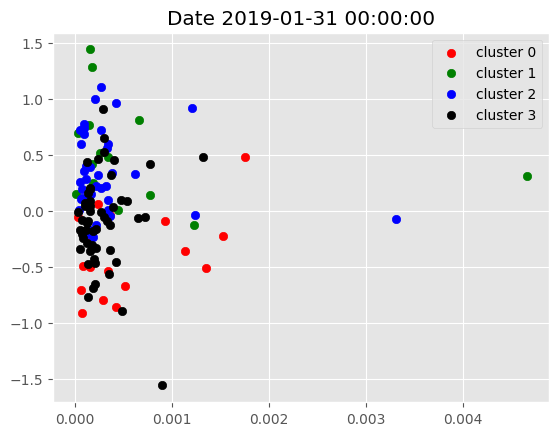

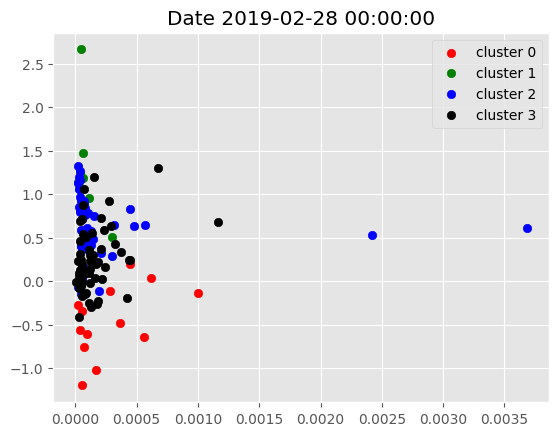

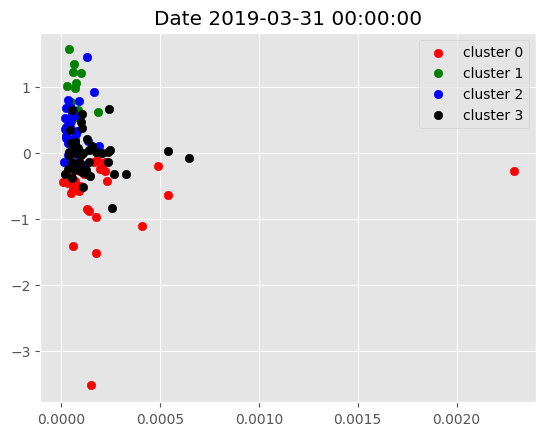

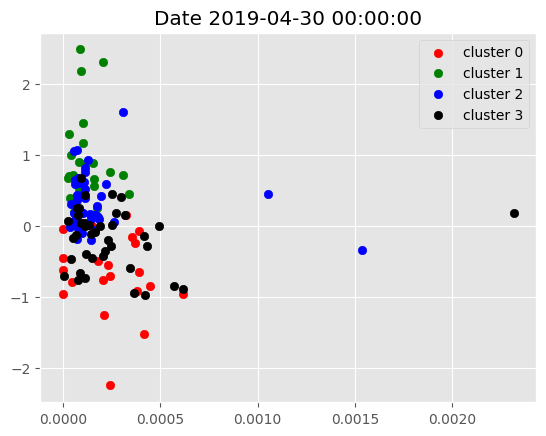

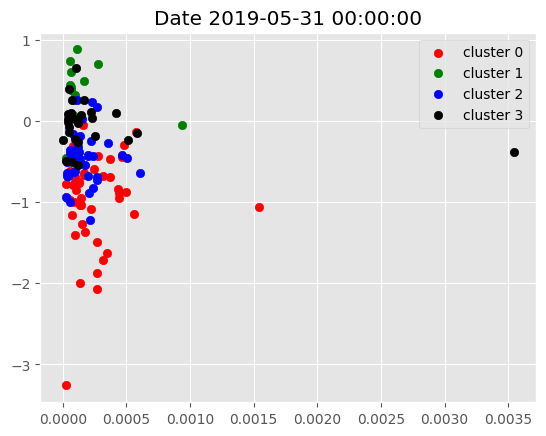

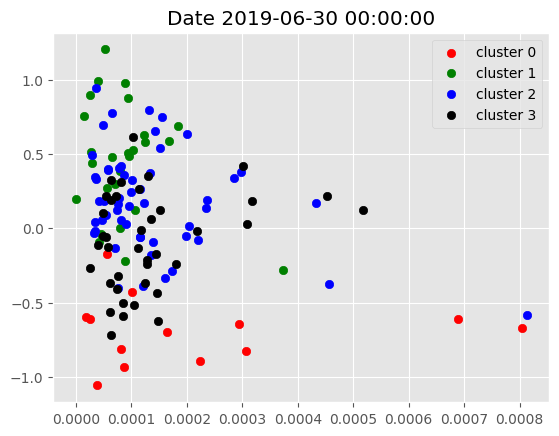

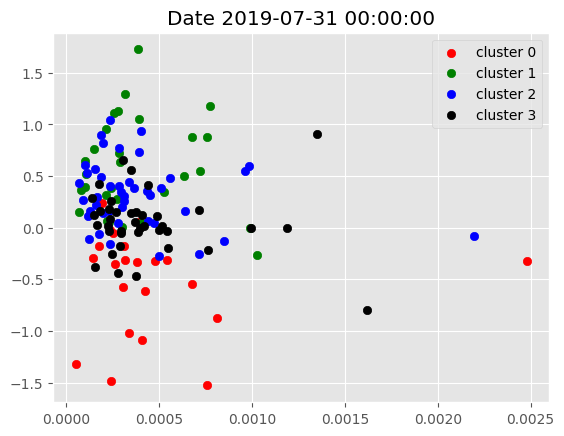

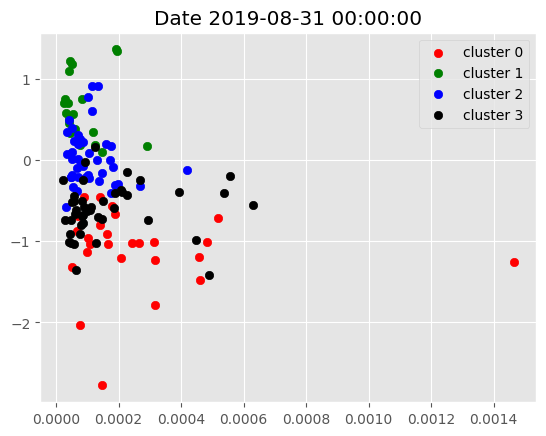

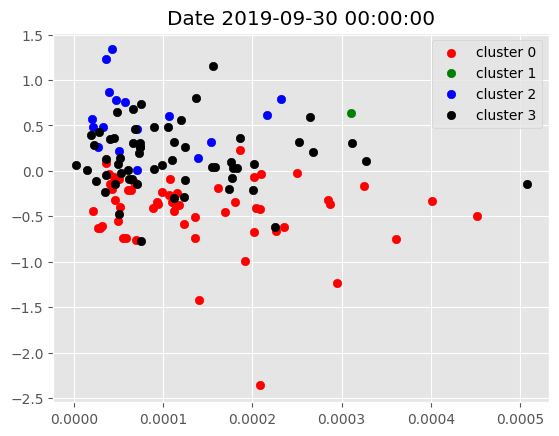

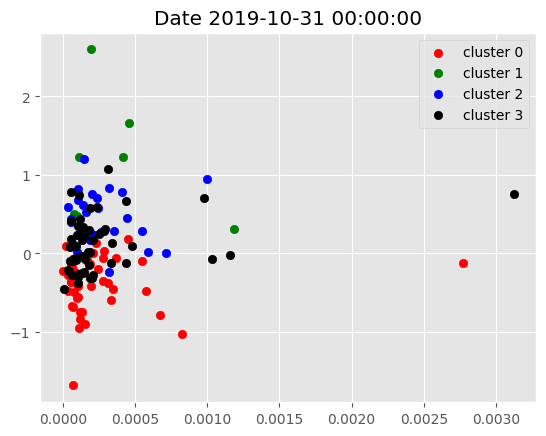

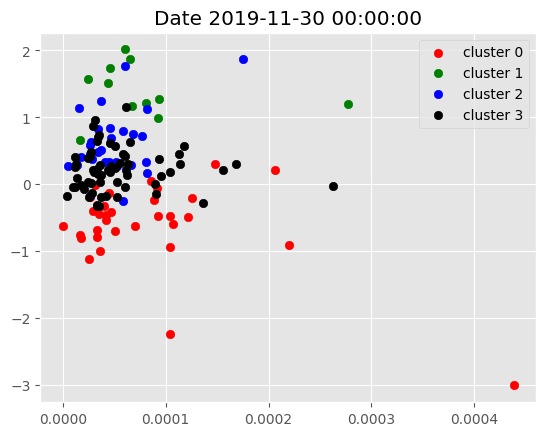

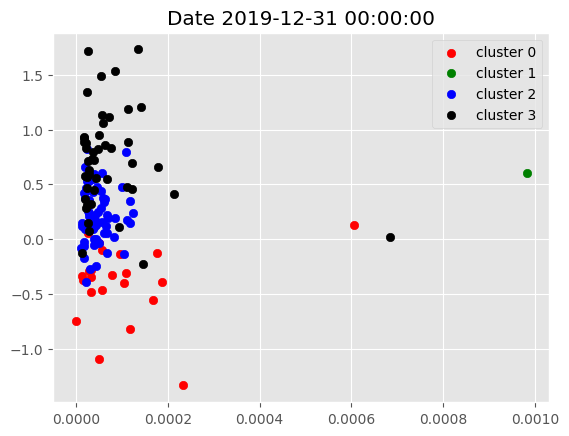

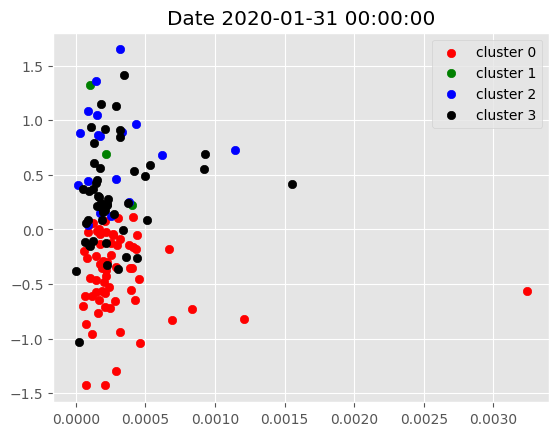

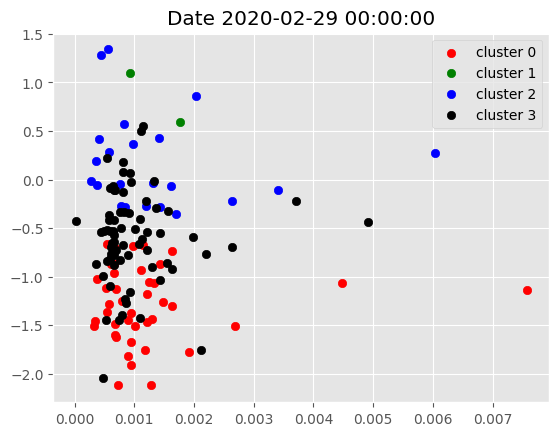

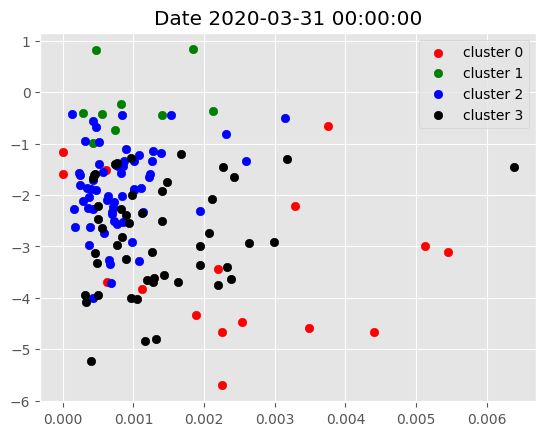

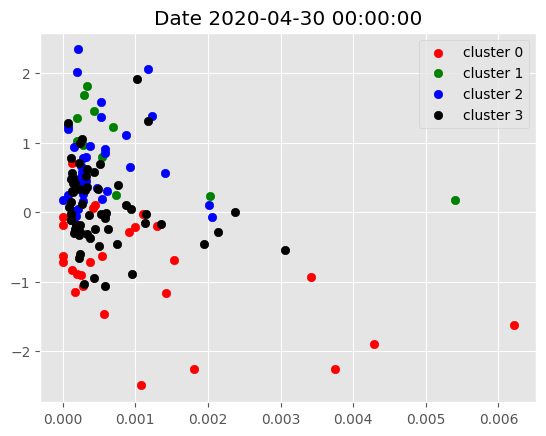

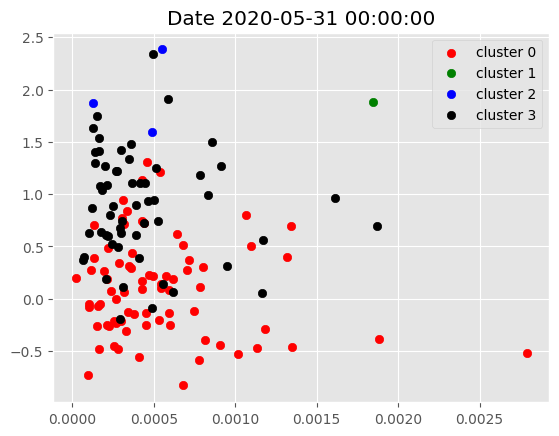

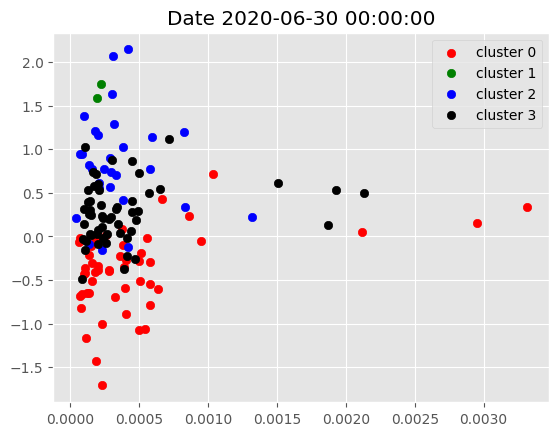

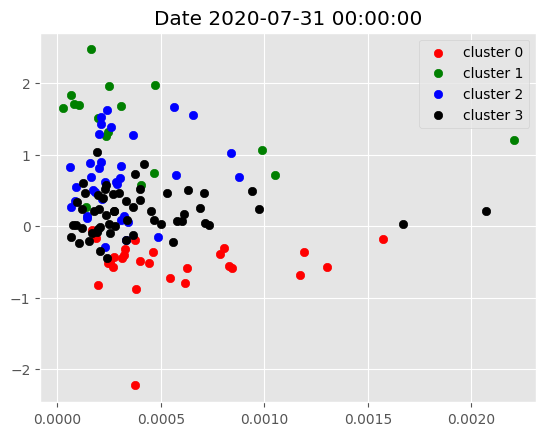

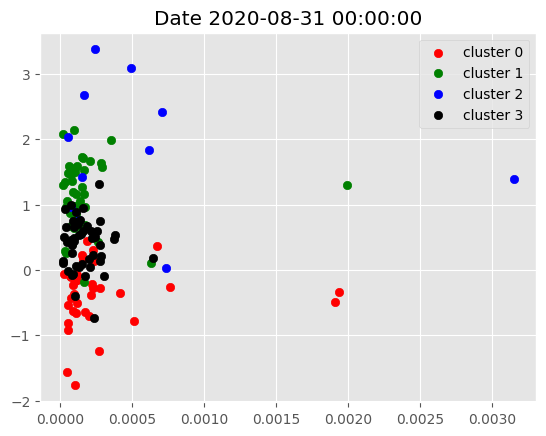

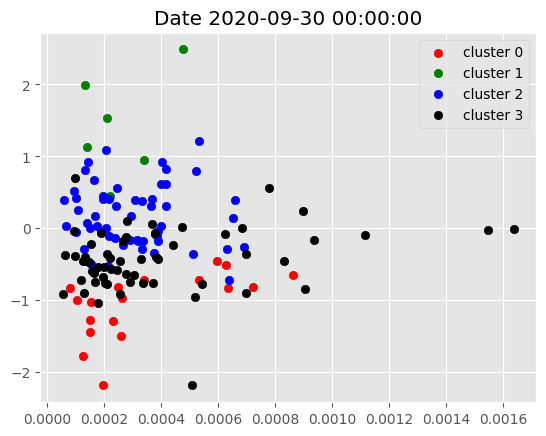

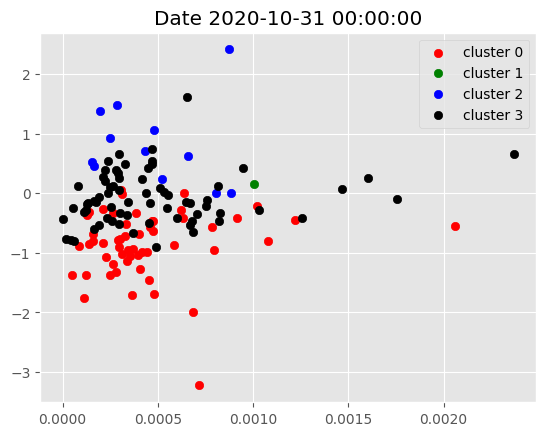

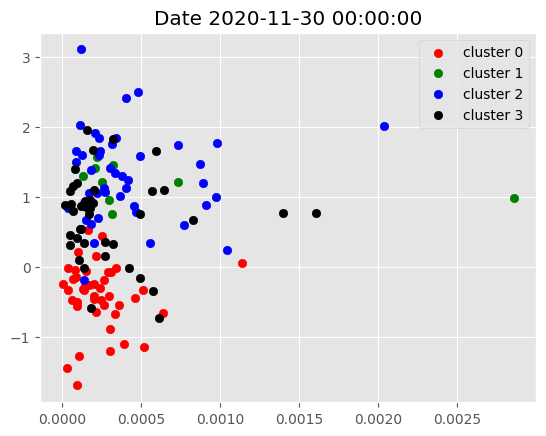

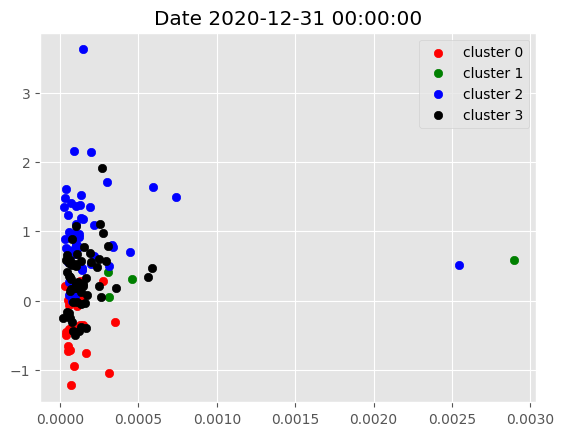

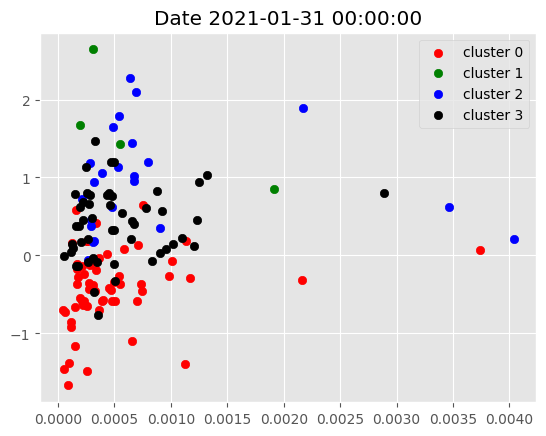

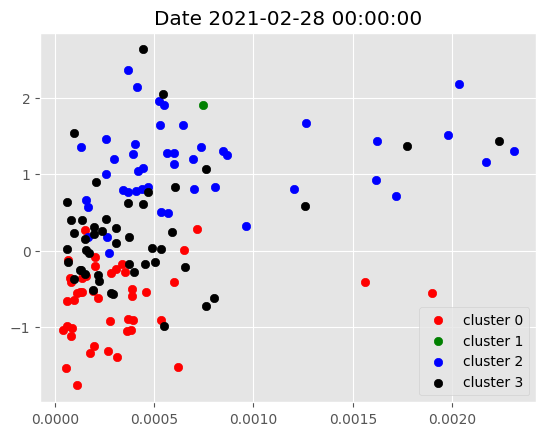

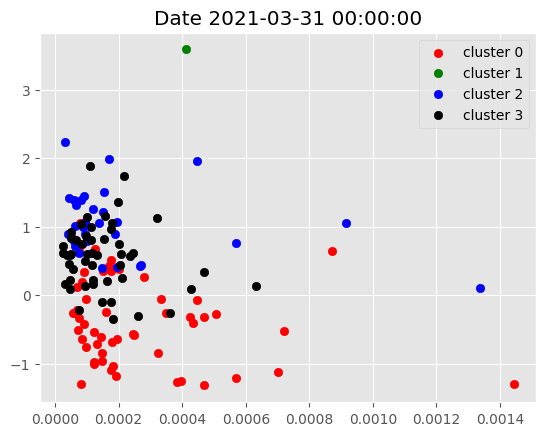

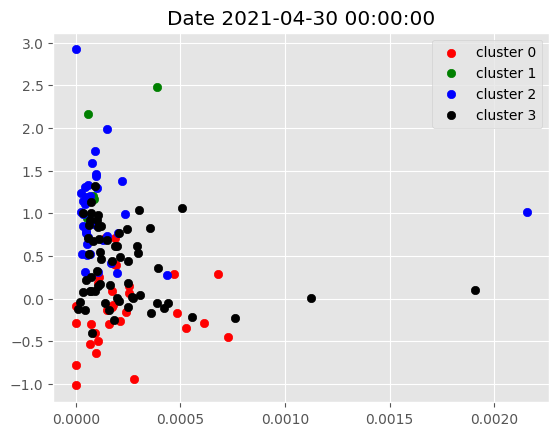

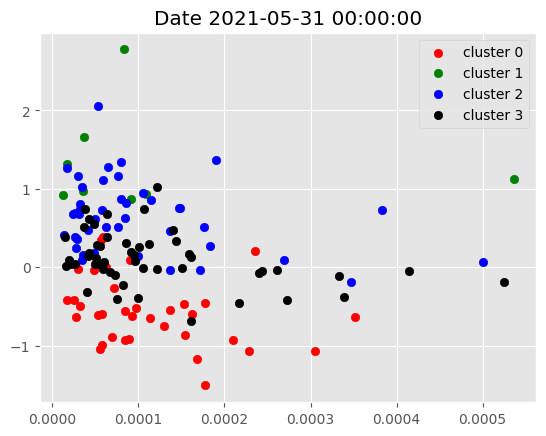

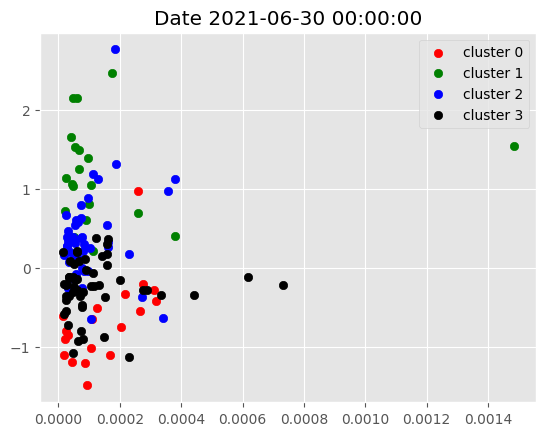

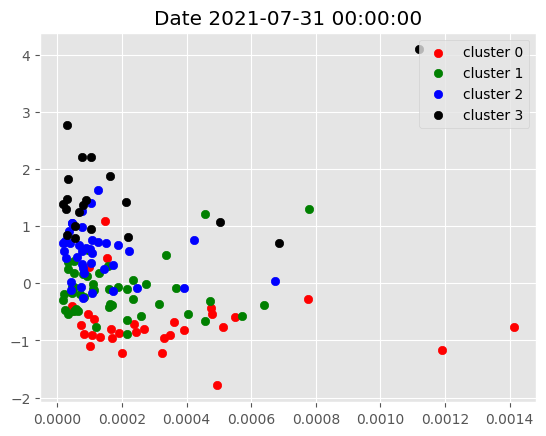

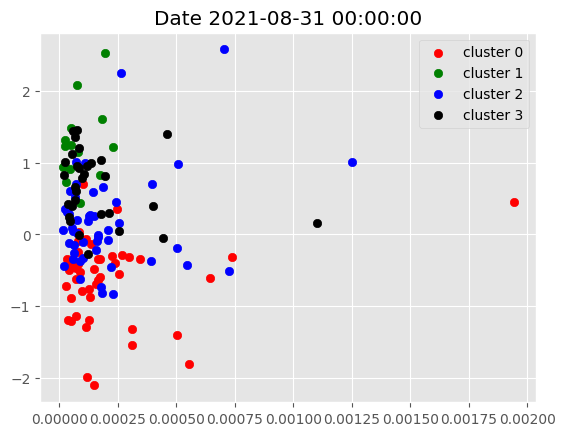

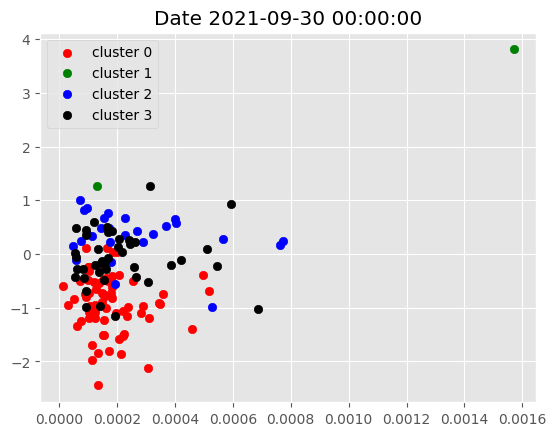

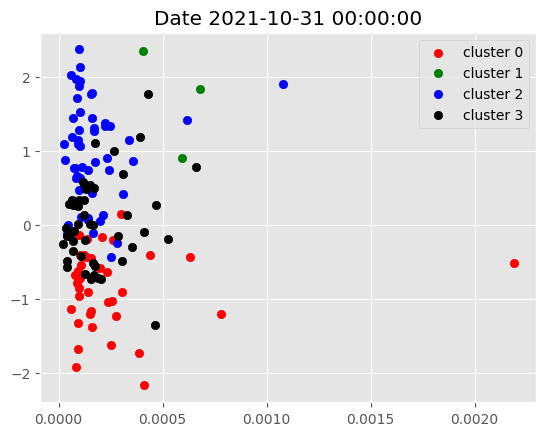

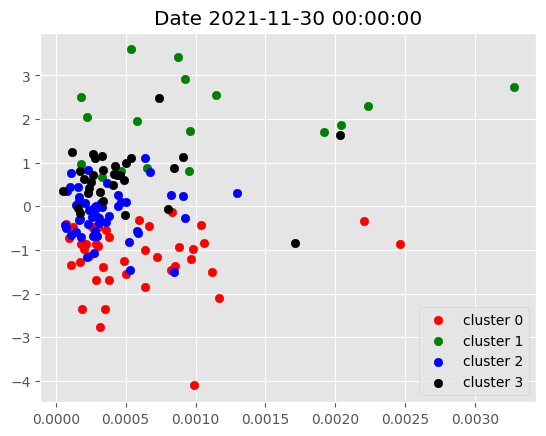

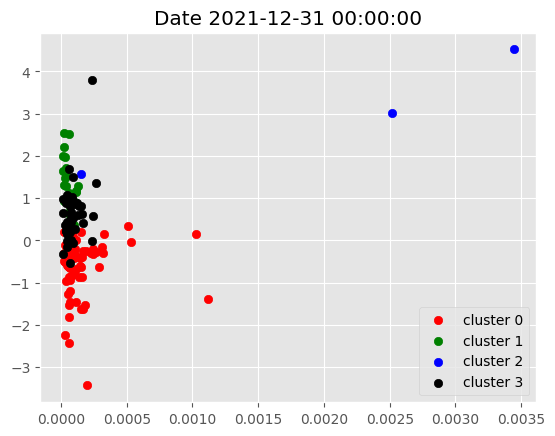

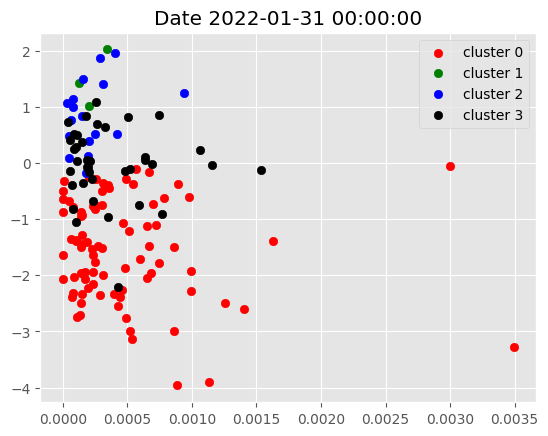

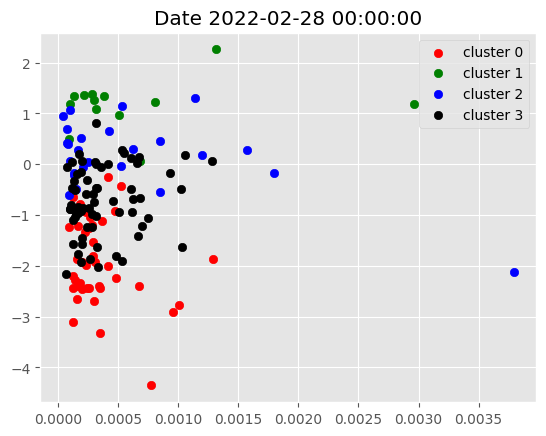

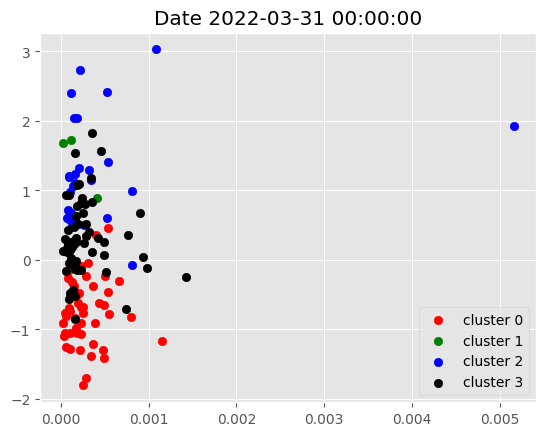

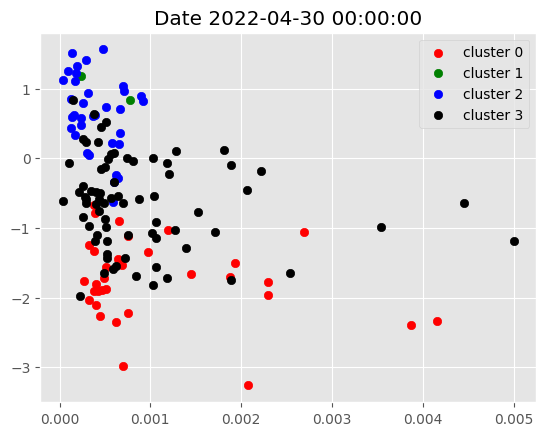

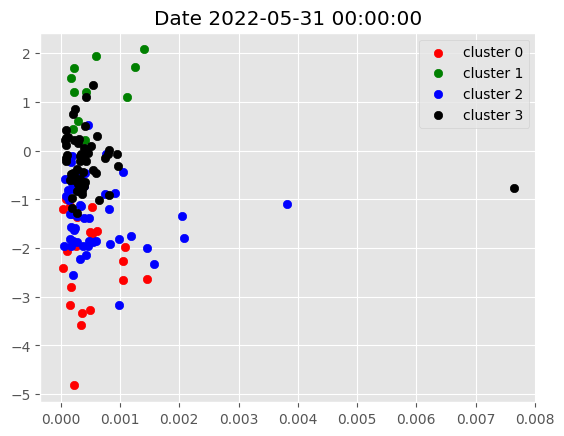

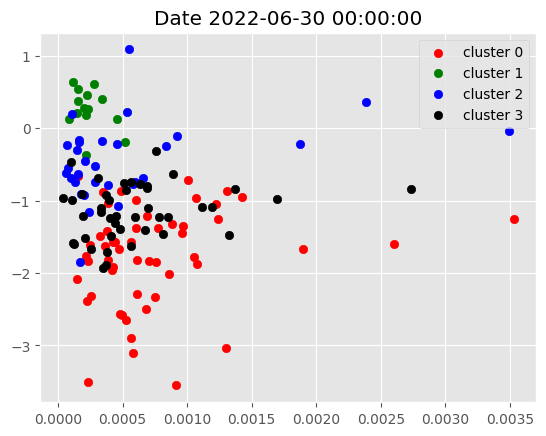

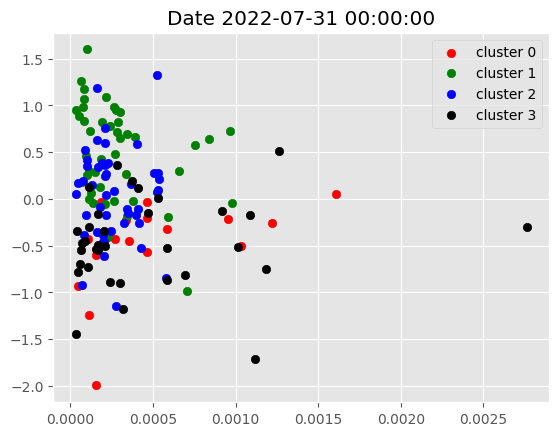

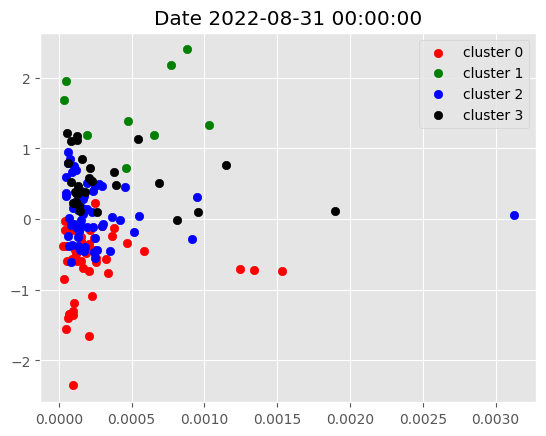

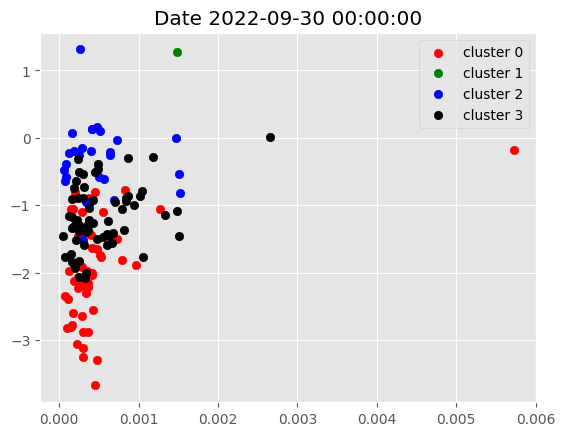

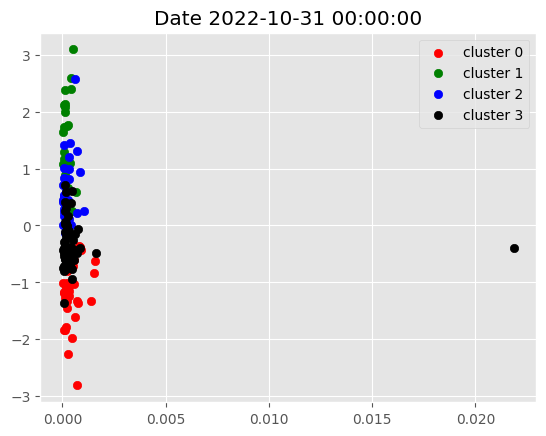

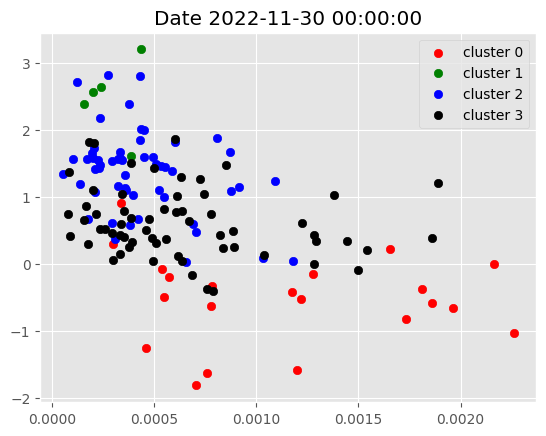

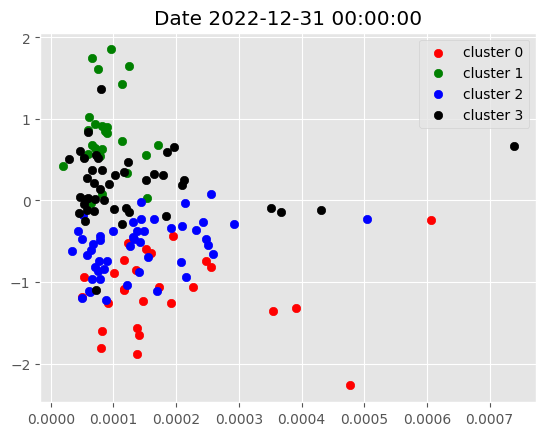

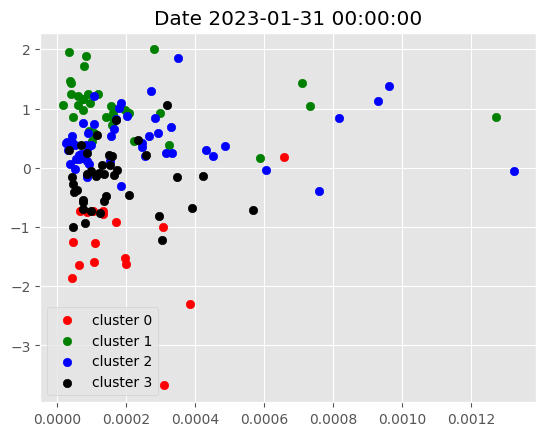

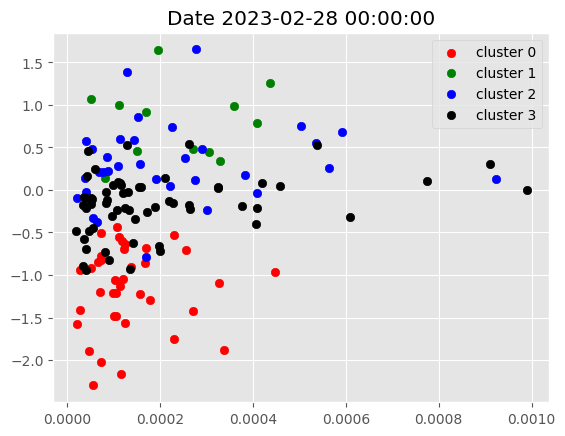

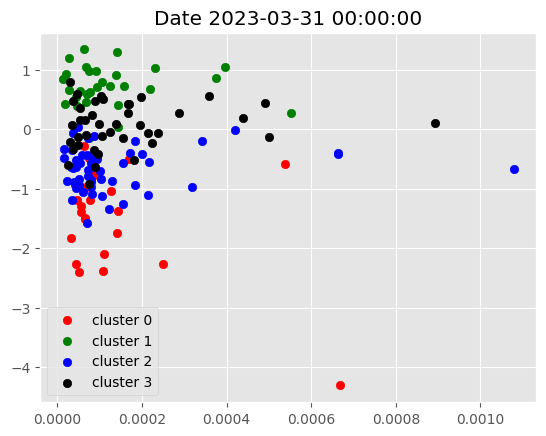

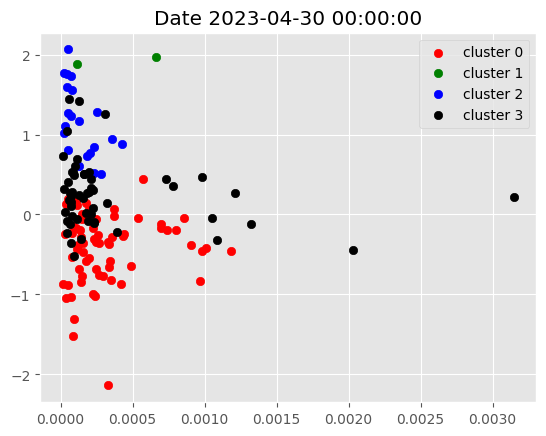

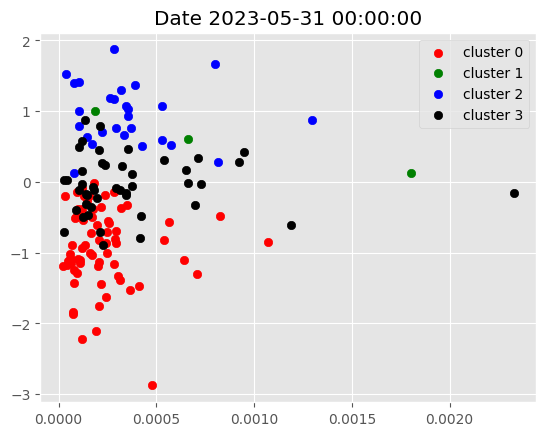

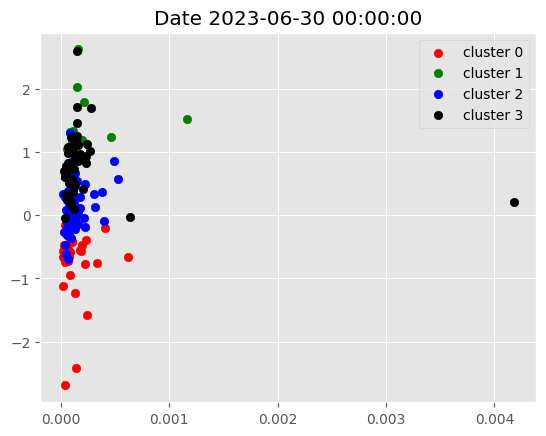

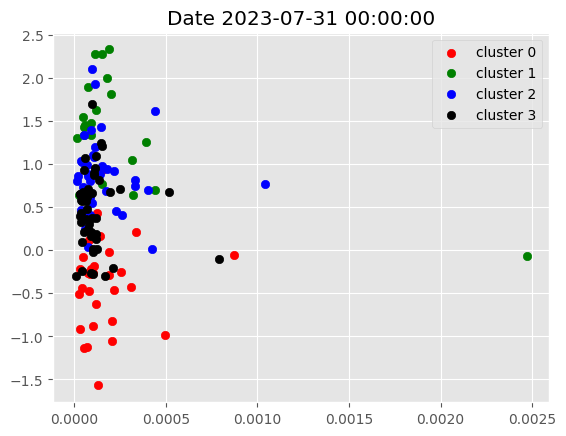

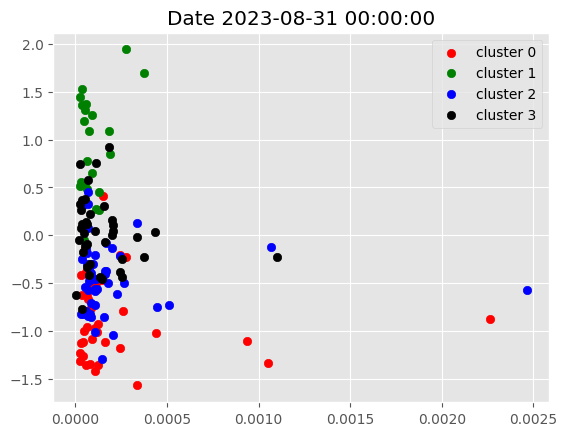

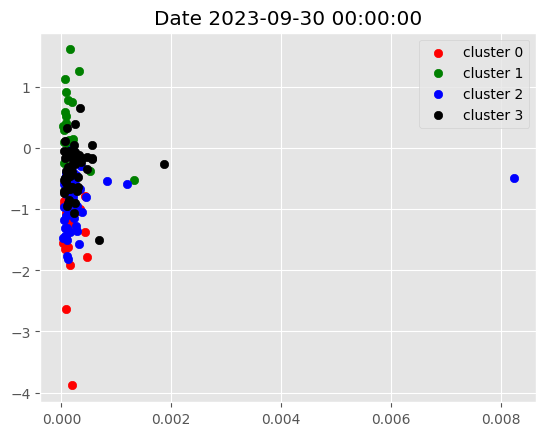

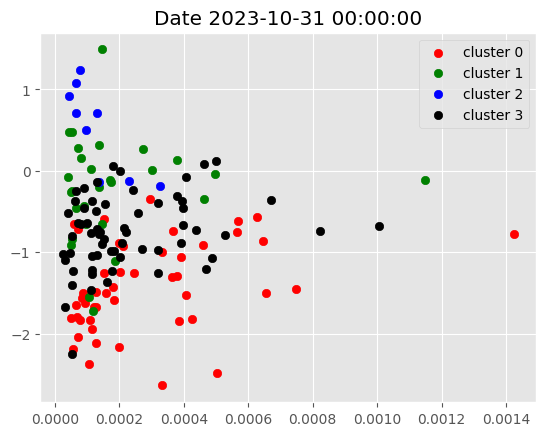

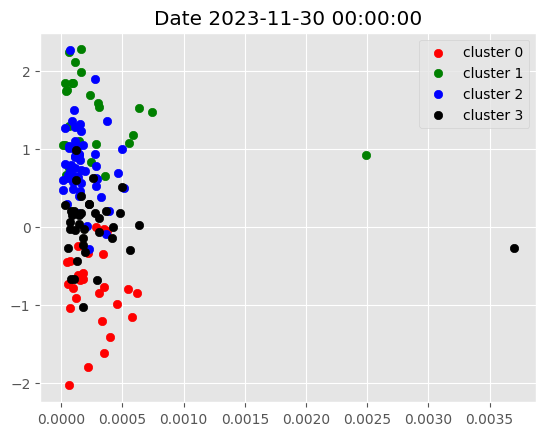

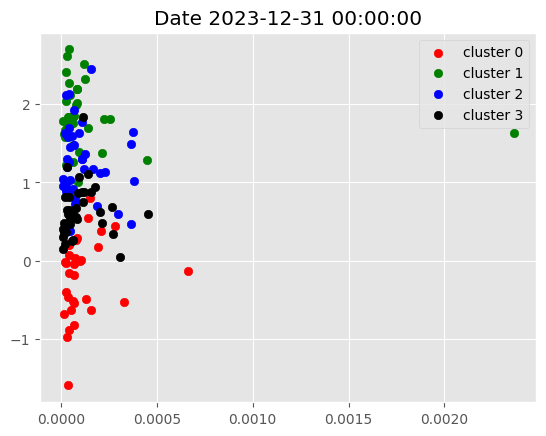

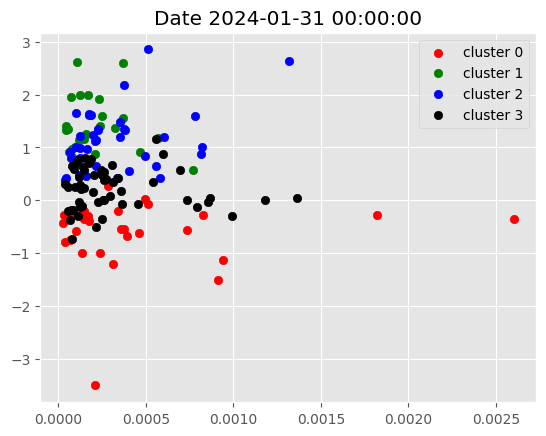

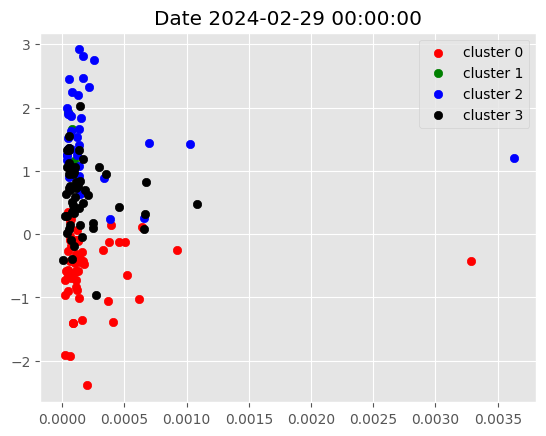

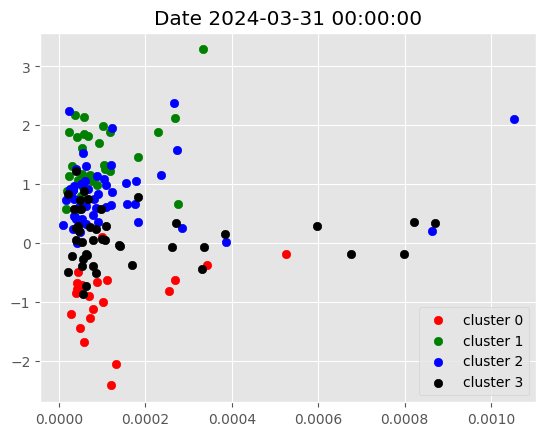

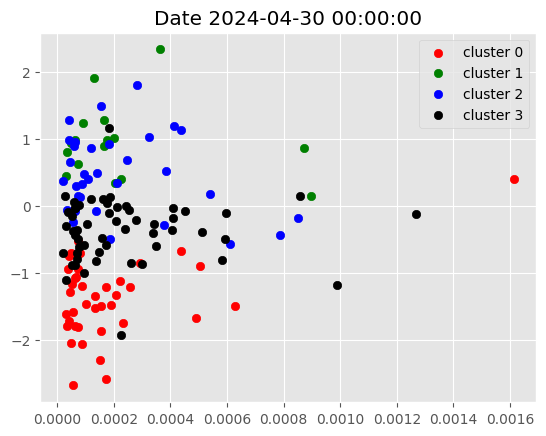

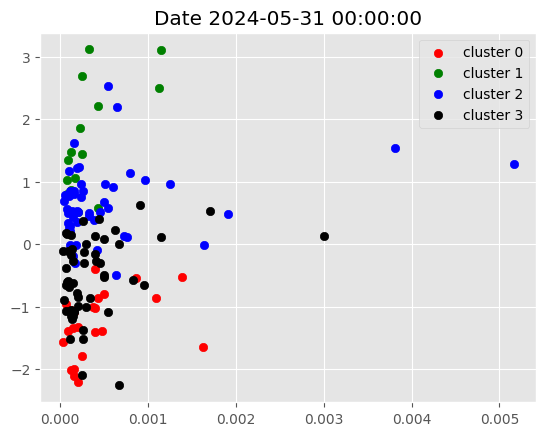

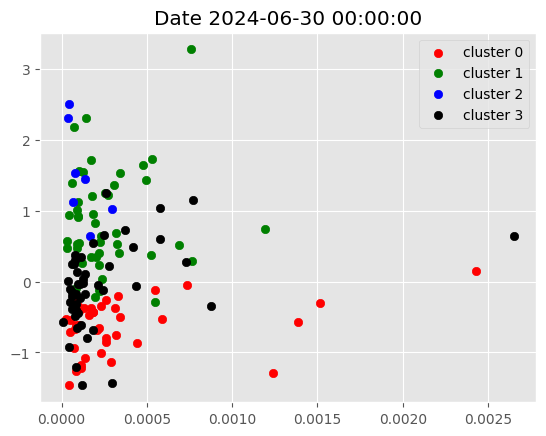

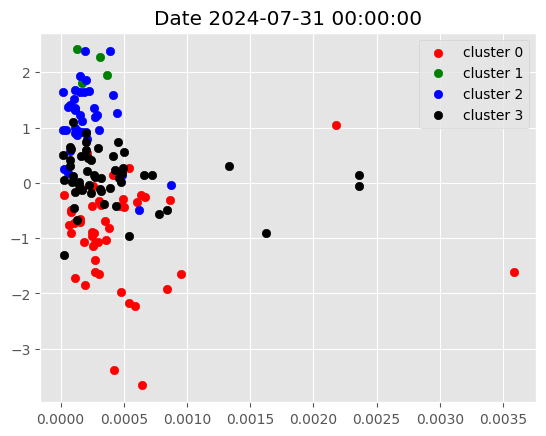

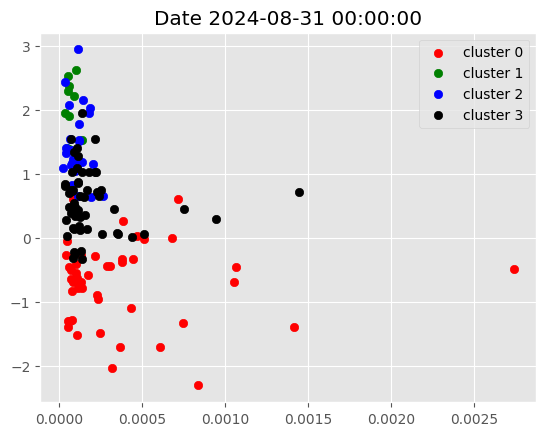

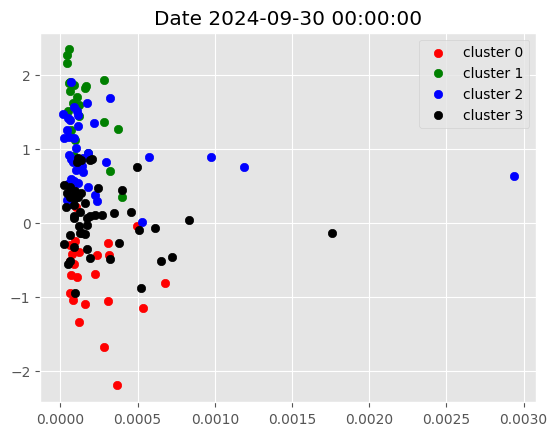

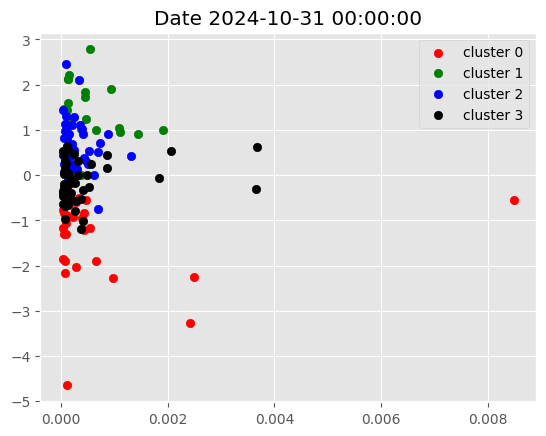

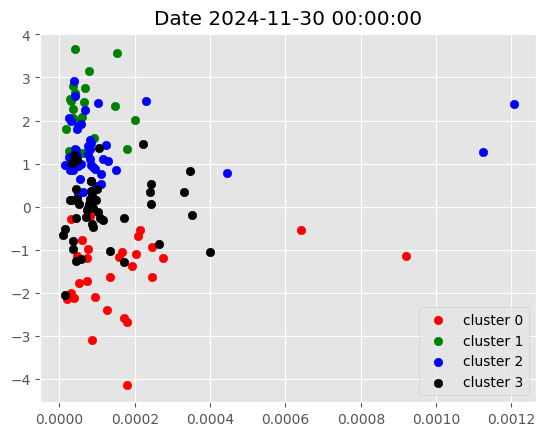

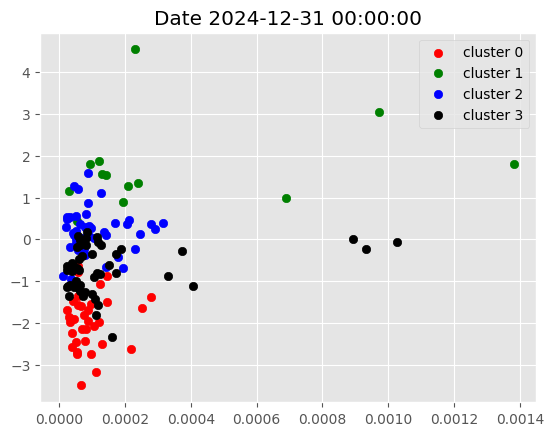

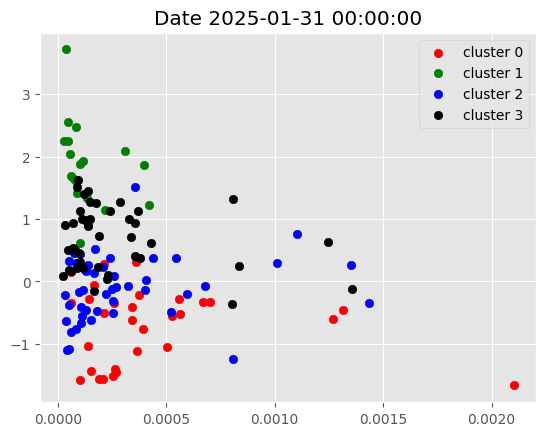

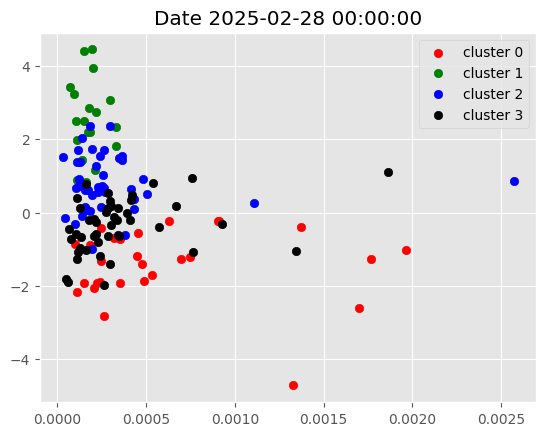

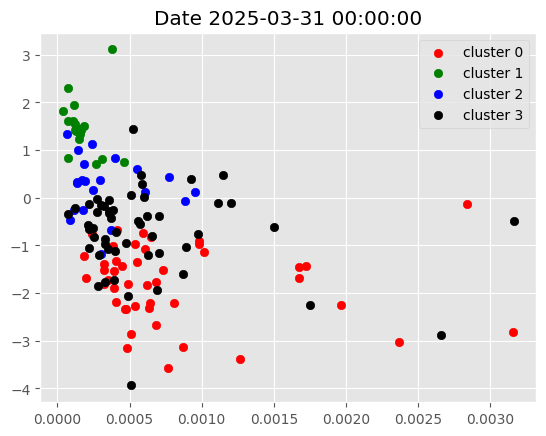

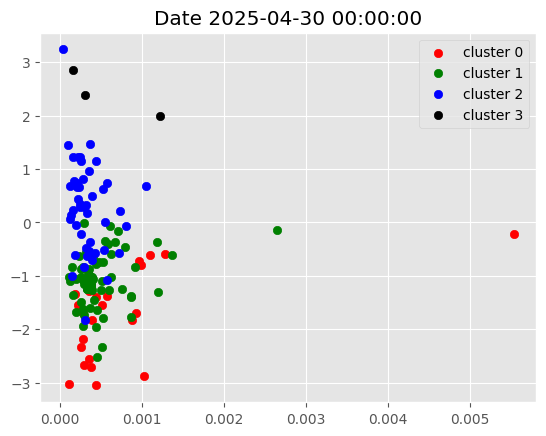

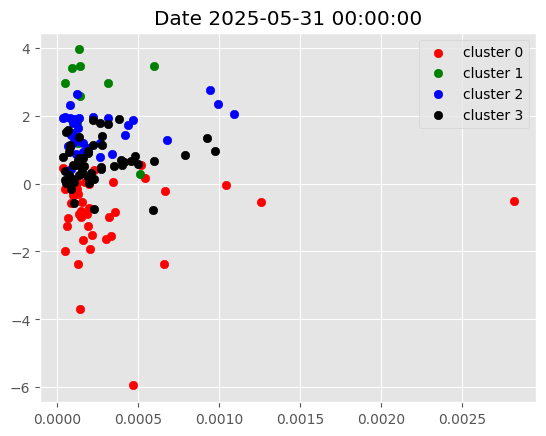

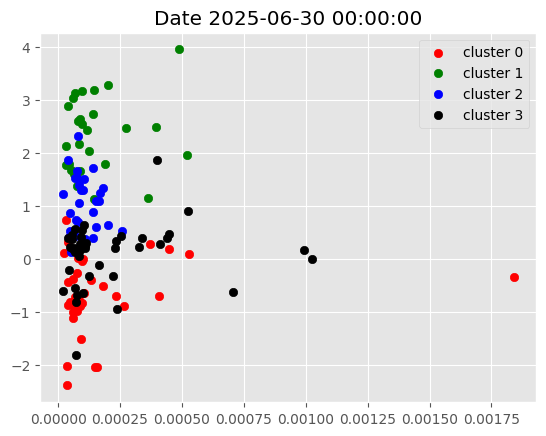

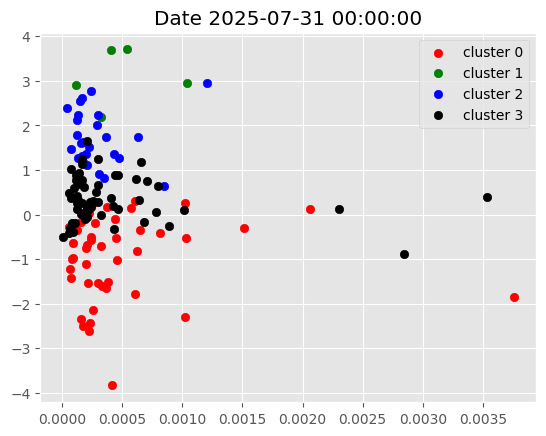

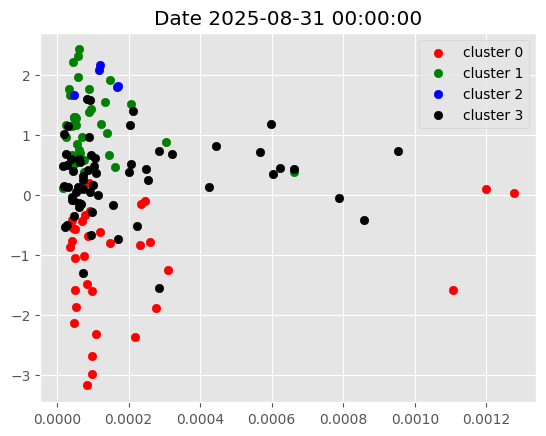

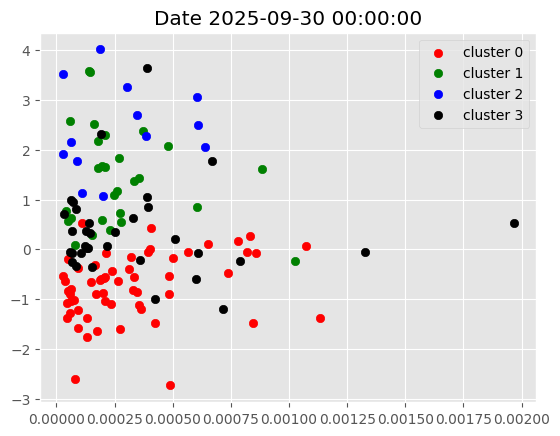

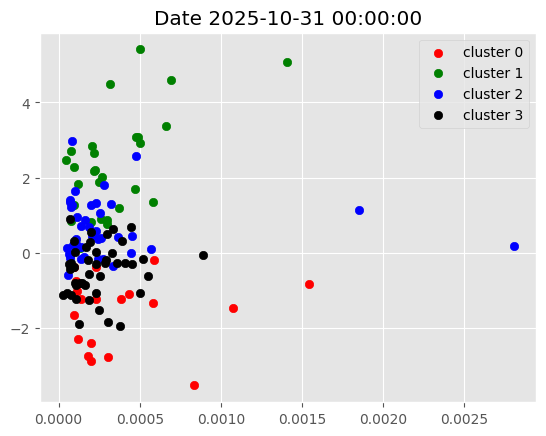

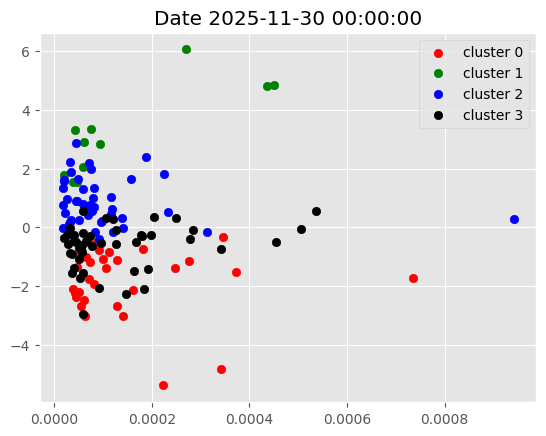

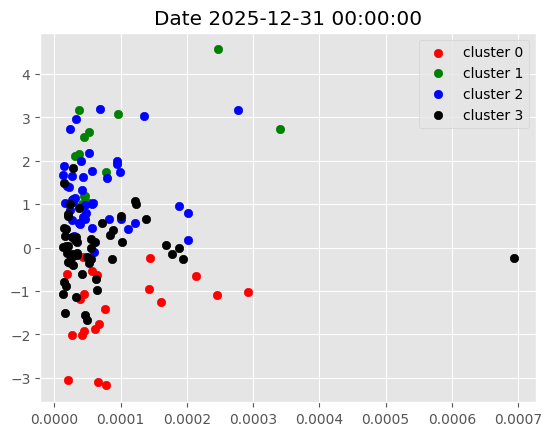

In [69]:
plt.style.use("ggplot")

for i in data.index.get_level_values("date").unique().tolist():
    g = data.xs(i, level=0)

    plt.title(f"Date {i}")

    plot_clusters(g)

#### 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.


In [71]:
filtered_df = data[data["cluster"] == 3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index + pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(["date", "ticker"])

dates = filtered_df.index.get_level_values("date").unique().tolist()

fixed_dates = {
    d.strftime("%Y-%m-%d"): filtered_df.xs(d, level=0).index.tolist() for d in dates
}
fixed_dates

{'2019-02-01': ['AAL',
  'AAPL',
  'ABT',
  'ACN',
  'ADBE',
  'AMZN',
  'AXP',
  'AZO',
  'BIIB',
  'BKNG',
  'BRK-B',
  'CAT',
  'CI',
  'CMCSA',
  'COP',
  'COST',
  'CSX',
  'CVX',
  'DIS',
  'EA',
  'EXPE',
  'F',
  'FCX',
  'GILD',
  'HAL',
  'ISRG',
  'JNJ',
  'JPM',
  'KO',
  'LMT',
  'LOW',
  'MDT',
  'MMM',
  'MO',
  'MRK',
  'MS',
  'MSFT',
  'MU',
  'NEE',
  'OXY',
  'PEP',
  'PFE',
  'PM',
  'PYPL',
  'RTX',
  'SLB',
  'STZ',
  'T',
  'TXN',
  'UAL',
  'WFC',
  'WMT',
  'XOM',
  'XYZ'],
 '2019-03-01': ['AAL',
  'AAPL',
  'AMAT',
  'AMD',
  'AMGN',
  'AMZN',
  'AVGO',
  'BAC',
  'BDX',
  'BIIB',
  'BMY',
  'C',
  'CAT',
  'COP',
  'DE',
  'DIS',
  'EA',
  'ELV',
  'EXPE',
  'F',
  'FCX',
  'FDX',
  'GLD',
  'GM',
  'GOOG',
  'GOOGL',
  'GS',
  'HAL',
  'HD',
  'ISRG',
  'JPM',
  'LUV',
  'MDT',
  'META',
  'MS',
  'MU',
  'NFLX',
  'NVDA',
  'NXPI',
  'OXY',
  'PFE',
  'PG',
  'QCOM',
  'SCHW',
  'SLB',
  'STZ',
  'TGT',
  'TSLA',
  'TXN',
  'UAL',
  'VRTX',
  'VZ',
  'WFC'

#### Define portfolio optimization function

We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [74]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns


def optimize_weights(prices, lower_bound=0):
    returns = expected_returns.mean_historical_return(prices=prices, frequency=252)

    cov = risk_models.sample_cov(prices=prices, frequency=252)

    ef = EfficientFrontier(
        expected_returns=returns,
        cov_matrix=cov,
        weight_bounds=(lower_bound, 0.1),
        solver="SCS",
    )

    weights = ef.max_sharpe()

    return ef.clean_weights()

Download Fresh Daily Prices Data only for short listed stocks.

In [78]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1],
                     auto_adjust=True, ignore_tz=True)

new_df

[*********************100%***********************]  164 of 164 completed


Price           Close                                                  \
Ticker            AAL        AAPL        ABBV        ABNB         ABT   
Date                                                                    
2018-01-31  52.943867   39.174080   78.986717         NaN   53.656609   
2018-02-01  52.515011   39.255970   81.886604         NaN   53.673859   
2018-02-02  50.780113   37.552658   81.063087         NaN   53.250908   
2018-02-05  48.592651   36.614422   77.079292         NaN   50.695816   
2018-02-06  49.979340   38.144611   78.268784         NaN   50.808044   
...               ...         ...         ...         ...         ...   
2025-12-23  15.600000  272.105377  225.096466  136.490005  123.139786   
2025-12-24  15.680000  273.554016  226.178711  136.779999  123.406746   
2025-12-26  15.440000  273.144409  226.267258  136.820007  123.436409   
2025-12-29  15.140000  273.504089  227.113373  136.619995  123.169449   
2025-12-30  15.330000  272.824707  226.031143  136.910004  124.365845   

Price                                                                   ...  \
Ticker             ACN        ADBE         ADI         ADP        ADSK  ...   
Date                                                                    ...   
2018-01-31  141.603027  199.759995   78.977608  103.538666  115.620003  ...   
2018-02-01  141.391541  199.380005   78.779915  100.850349  115.570000  ...   
2018-02-02  138.254623  195.639999   76.596596   99.300972  111.639999  ...   
2018-02-05  133.787109  190.270004   73.407578   95.532288  109.180000  ...   
2018-02-06  136.307281  194.470001   76.106636   94.594292  112.620003  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-23  268.493073  352.420013  275.866241  254.903885  297.579987  ...   
2025-12-24  267.709747  352.980011  276.693634  255.984940  298.209991  ...   
2025-12-26  268.810394  353.799988  275.975861  256.718872  300.709991  ...   
2025-12-29  269.058289  353.160004  274.769653  257.482544  301.230011  ...   
2025-12-30  267.729553  352.510010  273.962189  257.403229  299.540009  ...   

Price         Volume                                                   \
Ticker             V     VRTX        VZ     WDAY       WDC        WFC   
Date                                                                    
2018-01-31   7338200  2323800  17827000  1356100  11277649   18147900   
2018-02-01  11169700  5090000  18646100  1073200   4703530   15717600   
2018-02-02  13937700  3455100  15574000  1193900   6628759   18905300   
2018-02-05  16623900  2906900  22239600  1609800   6886480  103394400   
2018-02-06  19053300  3114600  34543900  2081400   6397763   83076900   
...              ...      ...       ...      ...       ...        ...   
2025-12-23   3703200   768500  19761800  2150400   3721100    8642100   
2025-12-24   2023600   310200   7949500   766200   3067000    5506800   
2025-12-26   2017000   388100  11875400  1648600   3351600    5169400   
2025-12-29   3989900   628200  16846700  1612400   3906300    8624200   
2025-12-30   3366500   685900  15581300  1889800   6008000    6417800   

Price                                               
Ticker           WMT      WYNN       XOM       XYZ  
Date                                                
2018-01-31  29438400  11253100  14404700  15334400  
2018-02-01  19160400   6416100  17971000  15925100  
2018-02-02  27759300   5398800  29822100  14284100  
2018-02-05  37684800   4916800  30452700  16631600  
2018-02-06  49241400   3672700  36262800  20298800  
...              ...       ...       ...       ...  
2025-12-23  20319900   1096700  12567600   5068200  
2025-12-24   9009600    615000   6137400   3017700  
2025-12-26   9003800    717300   8066100   3118400  
2025-12-29  12979600   1017200  14782500   4216700  
2025-12-30  11730600    689900  11150500   2958800  

[1990 rows x 820 columns]

- Calculate daily returns for each stock which could land up in our portfolio.

- Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

- If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

- Calculated each day portfolio return.


In [96]:
new_df['Close'][optimization_start_date:optimization_end_date]

Ticker,AAL,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,ADP,ADSK,...,V,VRTX,VZ,WDAY,WDC,WFC,WMT,WYNN,XOM,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,17.000000,242.525177,170.578766,131.479996,110.078773,341.018036,441.000000,207.272110,281.047119,293.320007,...,311.540283,405.760010,36.430397,251.839996,46.563934,68.361214,88.964104,82.812218,102.825630,86.750000
2025-01-03,16.969999,242.037827,172.270859,135.710007,110.457214,345.935486,430.570007,211.214523,283.026520,294.059998,...,312.045624,407.109985,36.475697,252.839996,48.219677,69.452034,89.735130,82.337875,103.352654,92.160004
2025-01-06,17.520000,243.668915,171.206177,135.199997,109.690620,343.471802,431.179993,213.793793,278.601959,292.510010,...,310.192657,402.489990,35.886799,254.139999,49.408798,70.153275,90.377655,83.612656,103.237663,91.940002
2025-01-07,17.690001,240.894073,170.664307,131.289993,110.039963,348.418701,422.630005,211.704880,279.834229,290.820007,...,308.835083,408.320007,35.261654,249.679993,48.821758,69.724731,89.764778,81.478119,104.205460,87.680000
2025-01-08,17.600000,241.381409,169.685181,130.800003,110.864777,349.728729,419.579987,216.186737,283.220612,296.369995,...,309.756653,412.109985,35.279774,254.690002,48.212151,69.705254,90.743385,80.213203,102.461525,86.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,15.600000,272.105377,225.096466,136.490005,123.139786,268.493073,352.420013,275.866241,254.903885,297.579987,...,352.652802,459.209991,38.657764,215.440002,178.164734,94.007965,110.672867,124.688042,118.629288,64.940002
2025-12-24,15.680000,273.554016,226.178711,136.779999,123.406746,267.709747,352.980011,276.693634,255.984940,298.209991,...,354.409180,462.989990,39.045116,216.850006,179.474106,94.833908,111.381416,124.747910,118.430618,66.050003
2025-12-26,15.440000,273.144409,226.267258,136.820007,123.436409,268.810394,353.799988,275.975861,256.718872,300.709991,...,354.269470,462.899994,39.200058,220.699997,181.453140,94.794106,111.511147,124.089348,118.321342,66.269997


In [169]:
returns_dataframe = np.log(new_df["Close"]).diff()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    try:
        end_date = (pd.to_datetime(start_date) + pd.offsets.MonthEnd(0)).strftime(
            "%Y-%m-%d"
        )

        cols = fixed_dates[start_date]

        optimization_start_date = (
            pd.to_datetime(start_date) - pd.DateOffset(months=12)
        ).strftime("%Y-%m-%d")

        optimization_end_date = (
            pd.to_datetime(start_date) - pd.DateOffset(days=1)
        ).strftime("%Y-%m-%d")

        optimization_df = new_df['Close'][optimization_start_date:optimization_end_date][cols]

        success = False
        try:
            weights = optimize_weights(
                prices=optimization_df,
                lower_bound=round(1 / (len(optimization_df.columns) * 2), 3),
            )

            weights = pd.DataFrame(weights, index=pd.Series(0))

            success = True
        except:
            print(
                f"Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights"
            )

        if success == False:
            weights = pd.DataFrame(
                [
                    1 / len(optimization_df.columns)
                    for i in range(len(optimization_df.columns))
                ],
                index=optimization_df.columns.tolist(),
                columns=pd.Series(0),
            ).T

        temp_df = returns_dataframe[start_date:end_date]
        # print('2')
        temp_df = (
            temp_df.stack()
            .to_frame("return")
            .reset_index(level=0)
            .merge(
                weights.stack().to_frame("weight").reset_index(level=0, drop=True),
                left_index=True,
                right_index=True,
            )
            .reset_index()
            .set_index(["Date", "Ticker"])
            .unstack()
            .stack()
        )

        temp_df.index.names = ["date", "ticker"]

        temp_df["weighted_return"] = temp_df["return"] * temp_df["weight"]
        # print('3')
        temp_df = (
            temp_df.groupby(level=0)["weighted_return"]
            .sum()
            .to_frame("Strategy Return")
        )

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df

Max Sharpe Optimization failed for 2020-04-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-05-01, Continuing with Equal-Weights
'return'


,Strategy Return
date,
2019-02-01,0.003026
2019-02-04,0.005588
2019-02-05,0.003353
2019-02-06,0.000755
2019-02-07,-0.008485
...,...
2025-12-23,0.001405
2025-12-24,0.003908
2025-12-26,-0.003292


#### 8. Visualize Portfolio returns and compare to SP500 returns.

In [170]:
spy = yf.download(tickers="SPY", start="2015-01-01", end=dt.date.today(), auto_adjust=True)

spy_ret = (
    np.log(spy[["Close"]])
    .diff()
    .dropna()
    .rename({"Close": "SPY Buy&Hold"}, axis=1)
)['SPY Buy&Hold']

portfolio_df = portfolio_df.merge(spy_ret, left_index=True, right_index=True)

portfolio_df.rename({"SPY" : "SPY Buy&Hold"}, axis=1, inplace=True)

portfolio_df

[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY Buy&Hold
2019-02-01,0.003026,0.000482
2019-02-04,0.005588,0.007011
2019-02-05,0.003353,0.004183
2019-02-06,0.000755,-0.001320
2019-02-07,-0.008485,-0.009578
...,...,...
2025-12-23,0.001405,0.004560
2025-12-24,0.003908,0.003511
2025-12-26,-0.003292,-0.000101
2025-12-29,-0.003558,-0.003570


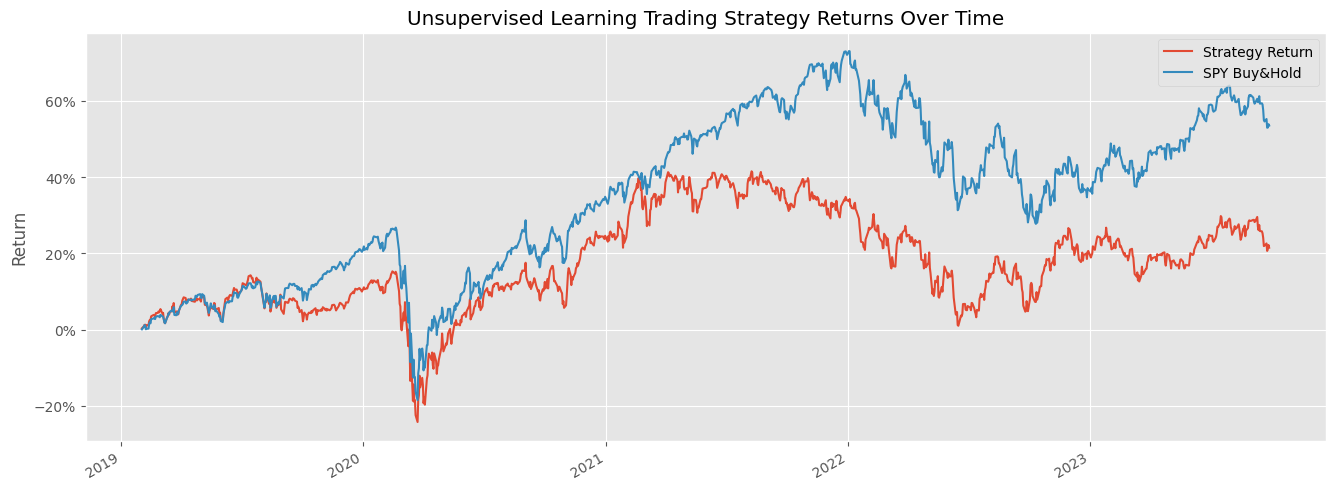

In [171]:
import matplotlib.ticker as mtick

plt.style.use("ggplot")

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()) - 1

portfolio_cumulative_return[:"2023-09-29"].plot(figsize=(16, 6))

plt.title("Unsupervised Learning Trading Strategy Returns Over Time")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel("Return")

plt.show()

In [172]:
import pandas as pd
import numpy as np
import json

# 1. Dates and Period
start_date = portfolio_df.index.min()
end_date = portfolio_df.index.max()
start_date_str = start_date.strftime('%Y-%m-%d %H:%M:%S')
end_date_str = end_date.strftime('%Y-%m-%d %H:%M:%S')
period_delta = end_date - start_date
period_str = str(period_delta)

# 2. Total Returns
strategy_total_return_pct = portfolio_cumulative_return['Strategy Return'].iloc[-1] * 100
benchmark_total_return_pct = portfolio_cumulative_return['SPY Buy&Hold'].iloc[-1] * 100

# 3. Initial and End Value (assuming an arbitrary starting capital)
initial_investment = 10000000.0 # Using an example starting value
strategy_end_value = initial_investment * (1 + portfolio_cumulative_return['Strategy Return'].iloc[-1])

# 4. Max Drawdown and Duration
def calculate_drawdown_metrics(returns_series):
    cumulative_returns = (1 + returns_series).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns / peak) - 1

    max_drawdown = drawdown.min() * 100 # as percentage
    end_date_dd = drawdown.idxmin()
    temp_peak = peak.loc[:end_date_dd]
    start_date_dd = temp_peak[temp_peak == temp_peak.max()].index[-1]
    duration_dd = end_date_dd - start_date_dd
    return max_drawdown, str(duration_dd)

strategy_max_drawdown_pct, strategy_max_drawdown_duration = calculate_drawdown_metrics(portfolio_df['Strategy Return'])

# 5. Annualized Returns (CAGR for Calmar Ratio)
def calculate_cagr_from_total_return(total_return_decimal, start_date_val, end_date_val):
    num_years = (end_date_val - start_date_val).days / 365.25
    if num_years <= 0:
        return 0
    return ((1 + total_return_decimal)**(1/num_years) - 1) * 100

strategy_cagr = calculate_cagr_from_total_return(portfolio_cumulative_return['Strategy Return'].iloc[-1], start_date, end_date)

# 6. Sharpe Ratio
# Daily returns for the strategy
daily_strategy_returns = portfolio_df['Strategy Return']
annualization_factor = np.sqrt(252) # Assuming 252 trading days in a year
risk_free_rate_annual = 0.02 # Assuming 2% annual risk-free rate, convert to daily
risk_free_rate_daily = (1 + risk_free_rate_annual)**(1/252) - 1

excess_returns = daily_strategy_returns - risk_free_rate_daily
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * annualization_factor if excess_returns.std() != 0 else 0.0

# 7. Calmar Ratio
calmar_ratio = strategy_cagr / abs(strategy_max_drawdown_pct) if strategy_max_drawdown_pct != 0 else 0.0

# 8. Sortino Ratio
# Calculate downside deviation
target_return_daily = risk_free_rate_daily
downside_returns = daily_strategy_returns[daily_strategy_returns < target_return_daily]
downside_deviation = downside_returns.std()

if downside_deviation == 0:
    sortino_ratio = 0.0
else:
    sortino_ratio = (excess_returns.mean() / downside_deviation) * annualization_factor

# Construct the report dictionary
report_json_data = {
    "Start": start_date_str,
    "End": end_date_str,
    "Period": period_str,
    "Start Value": initial_investment,
    "End Value": strategy_end_value,
    "Total Return [%]": strategy_total_return_pct,
    "Benchmark Return [%]": benchmark_total_return_pct,
    "Max Gross Exposure [%]": 100.0, # Assuming full investment
    "Total Fees Paid": None, # Not calculable from this data
    "Max Drawdown [%]": strategy_max_drawdown_pct,
    "Max Drawdown Duration": strategy_max_drawdown_duration,
    "Total Trades": None, # Not calculable from this data
    "Total Closed Trades": None, # Not calculable from this data
    "Total Open Trades": None, # Not calculable from this data
    "Open Trade PnL": None, # Not calculable from this data
    "Win Rate [%]": None, # Not calculable from this data
    "Best Trade [%]": None, # Not calculable from this data
    "Worst Trade [%]": None, # Not calculable from this data
    "Avg Winning Trade [%]": None, # Not calculable from this data
    "Avg Losing Trade [%]": None, # Not calculable from this data
    "Avg Winning Trade Duration": None, # Not calculable from this data
    "Avg Losing Trade Duration": None, # Not calculable from this data
    "Profit Factor": None, # Not calculable from this data
    "Expectancy": None, # Not calculable from this data
    "Sharpe Ratio": sharpe_ratio,
    "Calmar Ratio": calmar_ratio,
    "Omega Ratio": None, # More complex, requires more granular data
    "Sortino Ratio": sortino_ratio
}

print(json.dumps(report_json_data, indent=4))


{
    "Start": "2019-02-01 00:00:00",
    "End": "2025-12-30 00:00:00",
    "Period": "2524 days 00:00:00",
    "Start Value": 10000000.0,
    "End Value": 19199847.6543604,
    "Total Return [%]": 91.99847654360399,
    "Benchmark Return [%]": 146.84844977069642,
    "Max Gross Exposure [%]": 100.0,
    "Total Fees Paid": null,
    "Max Drawdown [%]": -34.31072810636393,
    "Max Drawdown Duration": "0 days 00:00:00",
    "Total Trades": null,
    "Total Closed Trades": null,
    "Total Open Trades": null,
    "Open Trade PnL": null,
    "Win Rate [%]": null,
    "Best Trade [%]": null,
    "Worst Trade [%]": null,
    "Avg Winning Trade [%]": null,
    "Avg Losing Trade [%]": null,
    "Avg Winning Trade Duration": null,
    "Avg Losing Trade Duration": null,
    "Profit Factor": null,
    "Expectancy": null,
    "Sharpe Ratio": 0.4552695138168997,
    "Calmar Ratio": 0.28852879387954183,
    "Omega Ratio": null,
    "Sortino Ratio": 0.5696238816692065
}
